# DoriaNET — Building Damage Classification

**Members:** Alan Ray · Zach Shotwell · Miguel Moreno Coin

**Course:** Artificial Intelligence, Appalachian State University

**Repository:** https://github.com/zachshotwell/AI-FinalProject-GroupSCR

The DoriaNET dataset (Cheng, Behzadan & Noshadravan 2021) contains 1,458 (frame, building) instances drawn from 271 UAV video frames over Marsh Harbor, Bahamas, captured eight days after Hurricane Dorian. Each instance is labeled with a FEMA HAZUS damage state on the 0–5 ordinal scale. We benchmark four classifiers — an MLP baseline, a from-scratch CNN, MobileNetV2, and MobileNetV1 (the paper's chosen backbone) — under a building-stratified train/val/test split, in which all frame appearances of a given physical building stay in the same partition. This is more rigorous than the row-level shuffle used in the original paper and lowers the achievable test accuracy accordingly; the headline result is that transfer learning is essential when only ~800 training instances are available across six classes.

## Setup

In [2]:
!git clone https://github.com/zachshotwell/AI-FinalProject-GroupSCR
%cd AI-FinalProject-GroupSCR
%cd DoriaNETProject
!ls

Cloning into 'AI-FinalProject-GroupSCR'...
remote: Enumerating objects: 2288, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 2288 (delta 8), reused 0 (delta 0), pack-reused 2260 (from 4)
Receiving objects: 100% (2288/2288), 93.63 MiB | 17.15 MiB/s, done.
Resolving deltas: 100% (1765/1765), done.
/content/AI-FinalProject-GroupSCR
/content/AI-FinalProject-GroupSCR/DoriaNETProject
 data
 DoriaNET.ipynb
'DoriaNET report.pdf'
'main paper. Deep learning for post-hurricane aerial damage assessmentof buildings.pdf'
 README.md


In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

print(f"TF version: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

DATA_ROOT = Path("data")
FRAME_DIR = DATA_ROOT / "FRAME"
MASK_DIR  = DATA_ROOT / "MASK"
JSON_DIR  = DATA_ROOT / "JSON"

TF version: 2.20.0
GPU available: True


## Data Reconnaissance

Before building the loader, we inspect file counts and one sample of each file type
across the FRAME, MASK, and JSON folders to confirm the on-disk layout matches the
schema described in the dataset paper.

This check is used to verify:
- file counts in each folder
- naming convention and per-folder file extensions
- frame and mask image dimensions
- rough alignment with the paper's stated 271-frame, 1,458-mask, 271-JSON layout

This section is exploratory only; final parsing and integrity checks are done in the
data preparation and EDA sections.

In [4]:
frame_files = sorted(FRAME_DIR.glob("*.jpg"))
mask_files  = sorted(MASK_DIR.glob("*.jpg"))
json_files  = sorted(JSON_DIR.glob("*.json"))

print(f"FRAME : {len(frame_files):>5} files")
print(f"MASK  : {len(mask_files):>5} files")
print(f"JSON  : {len(json_files):>5} files")

# Resolution check: paper specifies 1280×720
print(f"\nframe[0] shape: {plt.imread(frame_files[0]).shape}")
print(f"mask[0]  shape: {plt.imread(mask_files[0]).shape}")

FRAME :   271 files
MASK  :  1458 files
JSON  :   271 files

frame[0] shape: (720, 1280, 3)
mask[0]  shape: (720, 1280, 3)


## Data Preparation

This section parses the 271 per-frame JSON annotation files into a single tidy
table, with one row per (frame, building) instance. The DoriaNET schema stores
each building as a positional 7-element list rather than a named-field dict
(building ID, "lat, lon" string, mask filename, damage state, stories,
annotation effort, and one unused field). The parser:

- splits the `"lat, lon"` string into two float columns
- strips the `FRAME/` prefix from `Frame_Name` so it joins cleanly with on-disk filenames
- ignores the seventh field (NaN in all 1,458 records)

The resulting dataframe is the working table for the rest of the notebook: every
downstream cell selects rows from it by index.

In [5]:
def parse_frame_json(path):
    with open(path) as f:
        d = json.load(f)
    rows = []
    for b in d["Buildings"]:  # 7-element list per the DoriaNET schema
        lat, lon = (float(x) for x in b[1].split(","))
        rows.append({
            "frame_name":  Path(d["Frame_Name"]).name,
            "building_id": b[0],
            "lat":         lat,
            "lon":         lon,
            "mask_name":   b[2],
            "damage":      b[3],
            "stories":     b[4],
            "effort":      b[5],
        })
    return rows

records = [r for p in json_files for r in parse_frame_json(p)]
df = pd.DataFrame(records)

print(f"Building instances: {len(df)}")
print(f"Distinct frames   : {df['frame_name'].nunique()}")
print(f"Distinct buildings: {df['building_id'].nunique()}")
df.head()

Building instances: 1458
Distinct frames   : 271
Distinct buildings: 147


,frame_name,building_id,lat,lon,mask_name,damage,stories,effort
0,1_0373.jpg,B004,26.55438,-77.09680,1_0373_B0XX_0_Level1.jpg,1,1,1
1,1_0379.jpg,B001,26.55511,-77.10044,1_0379_B0XX_0_Level0.jpg,0,1,1
2,1_0379.jpg,B002,26.55516,-77.09986,1_0379_B0XX_0_Level2.jpg,2,1,1
3,1_0379.jpg,B003,26.55452,-77.09913,1_0379_B0XX_0_Level3.jpg,3,1,1
4,1_0405.jpg,B001,26.55511,-77.10044,1_0405_B0XX_0_Level0.jpg,0,1,1


## Exploratory Data Analysis

This section visualizes the dataset's class structure and confirms the mapping
between JSON annotations and on-disk files. The goals are to:

- show the distribution of damage states, annotation difficulty, and building stories
- summarize how many frames each building appears in (mean ≈ 10, max = 39)
- cross-tabulate damage state against annotation difficulty
- verify that every JSON-referenced frame and mask exists on disk and that masks
  share the parent frame's dimensions
- visualize one frame with all of its building masks colored by damage state

The damage distribution and integrity checks confirm we have the full Dataset 1
from Cheng et al. (2021), with no missing files or orphan masks.

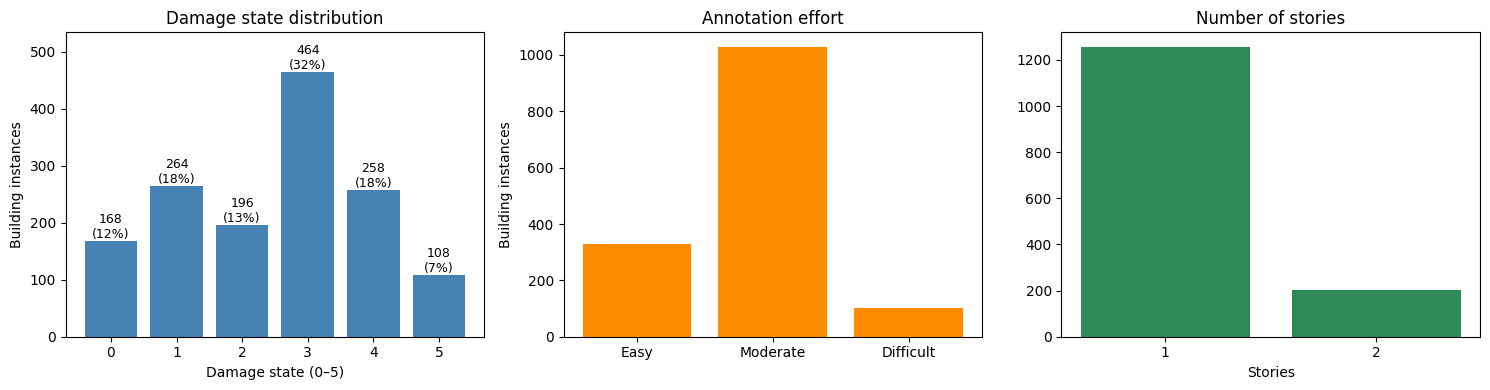

Frame appearances per building:
count    147.0
mean       9.9
std        7.9
min        1.0
25%        4.0
50%        8.0
75%       13.0
max       39.0
dtype: float64

Damage × Effort cross-tab:
effort    0     1    2   All
damage                      
0        26   126   16   168
1        65   193    6   264
2        42   134   20   196
3       133   300   31   464
4        50   195   13   258
5        12    81   15   108
All     328  1029  101  1458

Missing frames (referenced by JSON, not on disk): 0
Missing masks  (referenced by JSON, not on disk): 0
Orphan frames  (on disk, not referenced)        : 0
Orphan masks   (on disk, not referenced)        : 0


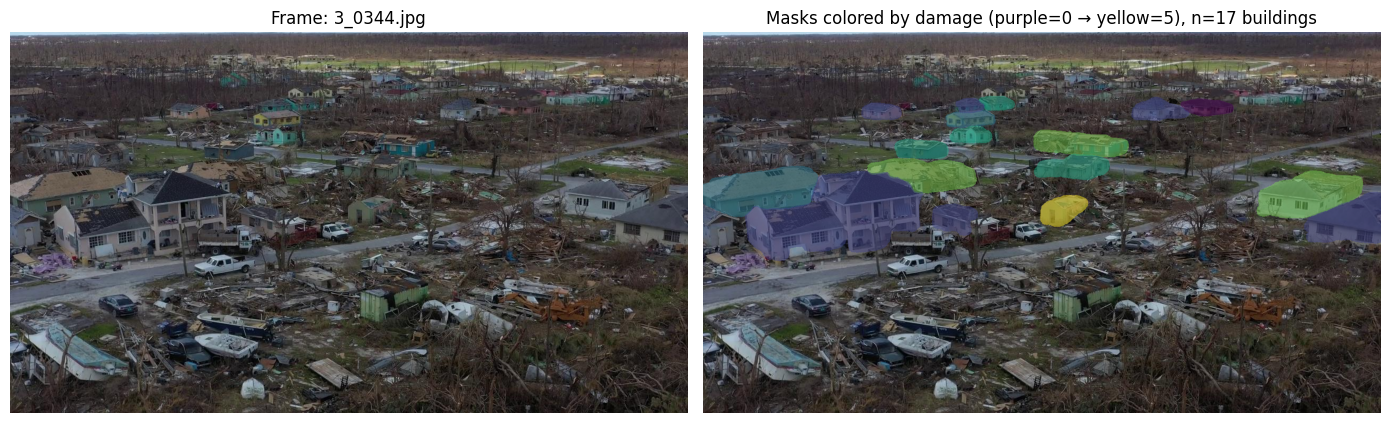

In [6]:
# 1) Distributions of damage / effort / stories
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

dmg = df["damage"].value_counts().sort_index()
axes[0].bar(dmg.index.astype(str), dmg.values, color="steelblue")
axes[0].set_title("Damage state distribution")
axes[0].set_xlabel("Damage state (0–5)")
axes[0].set_ylabel("Building instances")
axes[0].set_ylim(0, dmg.max() * 1.15)
for i, v in enumerate(dmg.values):
    axes[0].text(i, v + 5, f"{v}\n({100*v/len(df):.0f}%)", ha="center", fontsize=9)

eff = df["effort"].value_counts().sort_index()
axes[1].bar(["Easy", "Moderate", "Difficult"], eff.values, color="darkorange")
axes[1].set_title("Annotation effort")
axes[1].set_ylabel("Building instances")

stry = df["stories"].value_counts().sort_index()
axes[2].bar(stry.index.astype(str), stry.values, color="seagreen")
axes[2].set_title("Number of stories")
axes[2].set_xlabel("Stories")

plt.tight_layout()
plt.show()

# 2) Building structure and difficulty cross-tab
print("Frame appearances per building:")
print(df.groupby("building_id").size().describe().round(1))

print("\nDamage × Effort cross-tab:")
print(pd.crosstab(df["damage"], df["effort"], margins=True))

# 3) FRAME / MASK correspondence between JSON references and files on disk
frame_set_json = set(df["frame_name"])
mask_set_json  = set(df["mask_name"])
frame_set_disk = {p.name for p in frame_files}
mask_set_disk  = {p.name for p in mask_files}

print(f"\nMissing frames (referenced by JSON, not on disk): {len(frame_set_json - frame_set_disk)}")
print(f"Missing masks  (referenced by JSON, not on disk): {len(mask_set_json - mask_set_disk)}")
print(f"Orphan frames  (on disk, not referenced)        : {len(frame_set_disk - frame_set_json)}")
print(f"Orphan masks   (on disk, not referenced)        : {len(mask_set_disk - mask_set_json)}")

# 4) Sample frame: masks colored by damage state
sample_frame = df["frame_name"].value_counts().idxmax()
sample_rows = df[df["frame_name"] == sample_frame]

base = plt.imread(FRAME_DIR / sample_frame).astype(float) / 255.0
overlay = base.copy()
for _, row in sample_rows.iterrows():
    m = plt.imread(MASK_DIR / row["mask_name"])
    if m.ndim == 3:
        m = m.mean(axis=-1)
    color = np.array(plt.cm.viridis(row["damage"] / 5)[:3])
    overlay[m > 127] = 0.5 * overlay[m > 127] + 0.5 * color

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(base)
axes[0].set_title(f"Frame: {sample_frame}")
axes[0].axis("off")
axes[1].imshow(overlay)
axes[1].set_title(f"Masks colored by damage (purple=0 → yellow=5), n={len(sample_rows)} buildings")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Building-Stratified Train/Validation/Test Split

To prevent identity leakage, the 147 distinct physical buildings are split
between train, validation, and test rather than the 1,458 (frame, building)
instances. A row-level shuffle would place the same physical building in all
three splits at slightly different angles, letting the model memorize
building-specific features rather than learn damage patterns.

The split rule:

- 60% of buildings to train, 20% to validation, 20% to test
- stratified by each building's modal damage state, so all three splits see
  roughly the population class distribution
- random seed selected from a 50-seed search to maximize the smallest
  per-(split, class) cell count, ensuring rare classes (0, 5) are adequately
  represented in val and test

This split is more rigorous than the row-level split used in the paired paper.
We expect to underperform the paper's reported accuracy as a direct result of
removing the within-building leakage their split contains.

In [7]:
# One row per building, with its modal damage state for stratification
building_summary = (df.groupby("building_id")
                      .agg(modal_damage=("damage", lambda s: s.mode().iloc[0]))
                      .reset_index())

# 60/20/20 building-level split, stratified by modal damage class.
# seed=8 was chosen via search over 50 seeds to maximize the smallest (val/test, class) cell.
train_bld, temp_bld = train_test_split(
    building_summary, test_size=0.40,
    stratify=building_summary["modal_damage"], random_state=8)
val_bld, test_bld = train_test_split(
    temp_bld, test_size=0.50,
    stratify=temp_bld["modal_damage"], random_state=8)

train_ids = set(train_bld["building_id"])
val_ids   = set(val_bld["building_id"])
test_ids  = set(test_bld["building_id"])

df["split"] = df["building_id"].map(
    lambda b: "train" if b in train_ids else ("val" if b in val_ids else "test"))

print("Buildings and instances per split:")
for s in ["train", "val", "test"]:
    n_b = df.loc[df["split"] == s, "building_id"].nunique()
    n_i = (df["split"] == s).sum()
    print(f"  {s:5s}: {n_b:3d} buildings, {n_i:4d} instances ({100*n_i/len(df):.1f}%)")

print("\nDamage distribution per split (row-normalized):")
print(pd.crosstab(df["split"], df["damage"], normalize="index").round(3))

Buildings and instances per split:
  train:  88 buildings,  794 instances (54.5%)
  val  :  29 buildings,  315 instances (21.6%)
  test :  30 buildings,  349 instances (23.9%)

Damage distribution per split (row-normalized):
damage      0      1      2      3      4      5
split                                           
test    0.166  0.195  0.163  0.223  0.186  0.066
train   0.105  0.199  0.144  0.312  0.191  0.049
val     0.086  0.121  0.079  0.438  0.130  0.146


## Patch Extraction and Dataset Construction

This section converts the per-instance frame/mask pairs into fixed-size image
patches suitable for CNN input, and wraps them in `tf.data` pipelines for
training, validation, and testing.

For each (frame, building) instance:

1. Load the frame and its full-frame binary mask (`mean(channels) > 127`)
2. Crop the frame to the mask's bounding box
3. Pad the crop to square (avoids aspect-ratio distortion on resize)
4. Resize to 224×224 with bilinear interpolation, store as `uint8`

All 1,458 patches fit in a single `(1458, 224, 224, 3)` array (~219 MB),
which is held in memory rather than re-decoded each epoch.

Training-time augmentation follows Cheng et al. (2021) §3.1.2: horizontal flip,
±15° rotation, ±20% zoom. Augmentation is applied at the dataset level via
`.map()` rather than as model layers, so all three architectures share the
same training pipeline.

  processed 50/271 frames
  processed 100/271 frames
  processed 150/271 frames
  processed 200/271 frames
  processed 250/271 frames
  processed 271/271 frames

Patches: (1458, 224, 224, 3), uint8, 219 MB


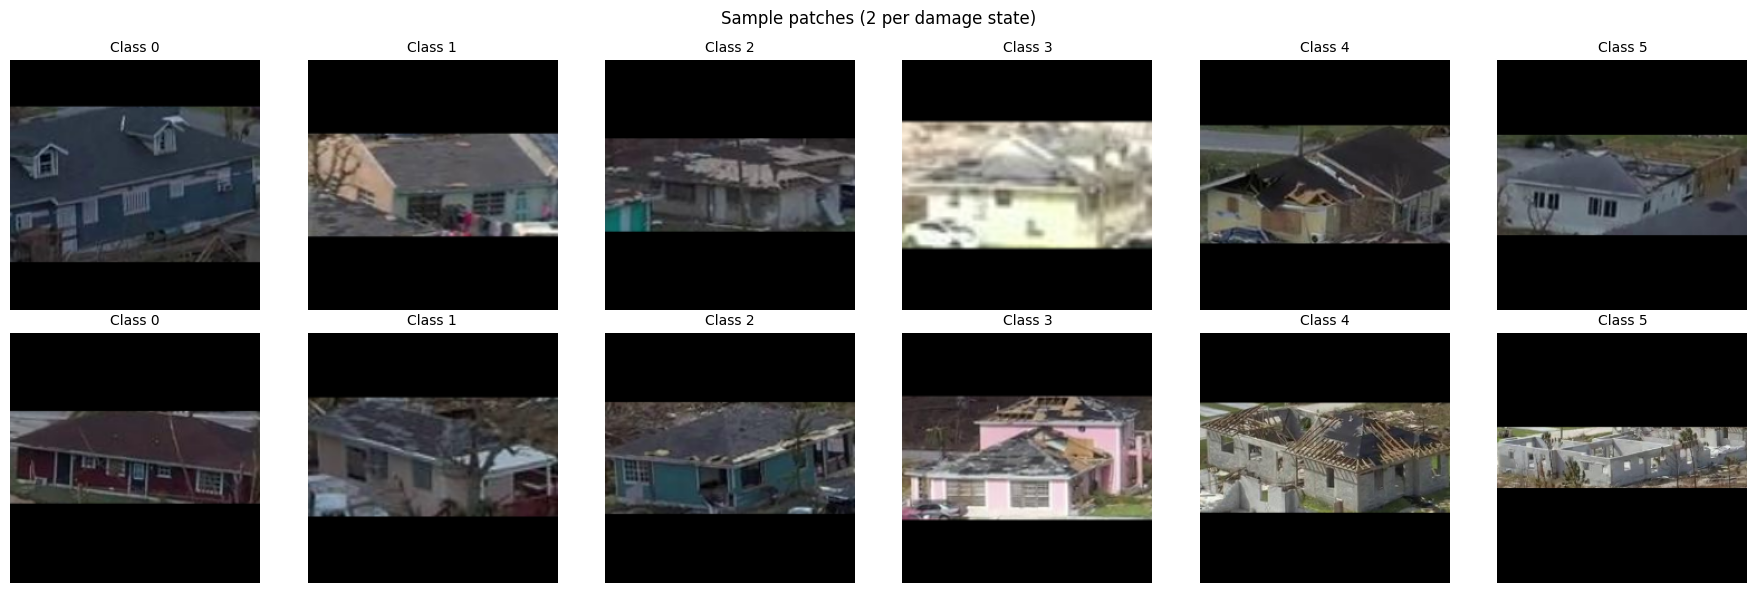

In [8]:
def extract_patch(frame, mask_bool, size=224):
    rows = np.where(np.any(mask_bool, axis=1))[0]
    cols = np.where(np.any(mask_bool, axis=0))[0]
    crop = frame[rows[0]:rows[-1]+1, cols[0]:cols[-1]+1]
    h, w = crop.shape[:2]
    side = max(h, w)
    out = np.zeros((side, side, 3), dtype=np.uint8)
    out[(side - h) // 2:(side - h) // 2 + h,
        (side - w) // 2:(side - w) // 2 + w] = crop
    return tf.image.resize(out, (size, size), method="bilinear").numpy().astype(np.uint8)


# Extract one patch per (frame, building) instance
patches = np.zeros((len(df), 224, 224, 3), dtype=np.uint8)
n_frames = df["frame_name"].nunique()
for i, (fname, group) in enumerate(df.groupby("frame_name")):
    frame = plt.imread(FRAME_DIR / fname)
    for idx, row in group.iterrows():
        mask = plt.imread(MASK_DIR / row["mask_name"])
        mb = mask.mean(axis=-1) > 127 if mask.ndim == 3 else mask > 127
        patches[idx] = extract_patch(frame, mb)
    if (i + 1) % 50 == 0 or i + 1 == n_frames:
        print(f"  processed {i+1}/{n_frames} frames")

print(f"\nPatches: {patches.shape}, {patches.dtype}, {patches.nbytes / 1e6:.0f} MB")

# Sample patches (2 per damage state) — sanity check on extraction
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for cls in range(6):
    for r, ix in enumerate(df[df["damage"] == cls].sample(2, random_state=42).index):
        axes[r, cls].imshow(patches[ix])
        axes[r, cls].set_title(f"Class {cls}", fontsize=10)
        axes[r, cls].axis("off")
plt.suptitle("Sample patches (2 per damage state)")
plt.tight_layout()
plt.show()

# Per-split feature/target arrays
train_idx = df.index[df["split"] == "train"].to_numpy()
val_idx   = df.index[df["split"] == "val"].to_numpy()
test_idx  = df.index[df["split"] == "test"].to_numpy()

X_train, y_train = patches[train_idx], df.loc[train_idx, "damage"].to_numpy()
X_val,   y_val   = patches[val_idx],   df.loc[val_idx,   "damage"].to_numpy()
X_test,  y_test  = patches[test_idx],  df.loc[test_idx,  "damage"].to_numpy()

# Augmentation pipeline (training only). Geometry follows Cheng et al. (2021) §3.1.2:
# horizontal flip, ±15° rotation, ±20% scale.
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=42),
    tf.keras.layers.RandomRotation(0.04, seed=42),
    tf.keras.layers.RandomZoom(0.2, seed=42),
], name="augment")

# tf.data pipelines
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=42, reshuffle_each_iteration=True)
            .batch(BATCH)
            .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))
val_ds  = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH).prefetch(AUTOTUNE)

## MLP, Standard CNN, MobileNetV2, and MobileNetV1

Four architectures are trained, in increasing order of architectural prior and external information:

- **MLP**: `AvgPool(4) → Flatten → Dense(256) → Dense(128) → Dense(6)` — fully-connected baseline applied to raw pixels with no spatial inductive bias.
- **Standard CNN**: three `Conv2D + MaxPool` blocks (32, 64, 128 filters) → `GlobalAveragePooling2D → Dense(64) → Dense(6)` — the canonical textbook vision architecture, trained from scratch.
- **MobileNetV2 with two-step transfer learning** — pretrained ImageNet backbone with custom head: `GlobalAveragePooling2D → Dropout(0.5) → Dense(6)`. Step 1 trains the head only at `lr=1e-3` for 25 epochs. Step 2 unfreezes the backbone and continues at `lr=1e-4`, gently adapting ImageNet features to UAV imagery. This recipe is from Cheng et al. (2021) §3.1.2.
- **MobileNetV1 with two-step transfer learning** — same recipe and head as MobileNetV2, but with the V1 backbone (the architecture Cheng et al. (2021) actually use). MobileNetV2 was adopted initially as the more recent variant of the MobileNet family; the M3 hyperparameter sweep flagged V1 as substantially better in our setting, motivating its inclusion as a primary model.

Training configuration:
- Loss: sparse categorical cross-entropy
- Optimizer: Adam, `lr=1e-3` for from-scratch training, `lr=1e-4` for MobileNet fine-tuning
- Callbacks: `EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)` and `ReduceLROnPlateau(factor=0.5, patience=5)`
- `clear_session()` and `set_seed(42)` before each model build, per Géron NB1 convention

We initially tried EMD² (squared earth-mover's distance) loss per the paper's recommendation but observed that the from-scratch models collapsed to majority-class prediction and that MobileNet underperformed cross-entropy in our setup. Cross-entropy across all four models is therefore both simpler and empirically better for our small-data regime; the discussion lives in the project documentation.

In [9]:
def make_callbacks(patience=10):
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
    ]


# --- MLP ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
mlp = tf.keras.Sequential([
    tf.keras.layers.Input((224, 224, 3)),
    tf.keras.layers.Rescaling(1/255),
    tf.keras.layers.AveragePooling2D(pool_size=4),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(6, activation="softmax"),
], name="mlp")
mlp.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print(f"MLP ({mlp.count_params():,} params)")
hist_mlp = mlp.fit(train_ds, validation_data=val_ds, epochs=100,
                   callbacks=make_callbacks(), verbose=2)


# --- Standard CNN ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
cnn = tf.keras.Sequential([
    tf.keras.layers.Input((224, 224, 3)),
    tf.keras.layers.Rescaling(1/255),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(6, activation="softmax"),
], name="cnn")
cnn.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print(f"\nCNN ({cnn.count_params():,} params)")
hist_cnn = cnn.fit(train_ds, validation_data=val_ds, epochs=100,
                   callbacks=make_callbacks(patience=10), verbose=2)


# --- MobileNetV2 with two-step transfer learning per Cheng et al. (2021) §3.1.2 ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
backbone = tf.keras.applications.MobileNetV2(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3))
backbone.trainable = False
inputs = tf.keras.Input((224, 224, 3))
x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)   # MobileNetV2 expects [-1, 1]
x = backbone(x, training=False)                              # keep BN in inference mode for step 1
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(6, activation="softmax")(x)
mbv2 = tf.keras.Model(inputs, outputs, name="mobilenetv2")

print(f"\nMobileNetV2 ({mbv2.count_params():,} params, step 1: head only, lr=1e-3)")
mbv2.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv2_s1 = mbv2.fit(train_ds, validation_data=val_ds, epochs=25,
                         callbacks=make_callbacks(), verbose=2)

print(f"\nMobileNetV2 step 2: full fine-tune, lr=1e-4")
backbone.trainable = True
mbv2.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv2_s2 = mbv2.fit(train_ds, validation_data=val_ds, epochs=100,
                         initial_epoch=len(hist_mbv2_s1.history["loss"]),
                         callbacks=make_callbacks(), verbose=2)

# Concatenated history for plotting (preserves the step1/step2 boundary)
hist_mbv2 = {k: hist_mbv2_s1.history[k] + hist_mbv2_s2.history[k]
             for k in hist_mbv2_s1.history}

# --- MobileNetV1 with two-step transfer learning per Cheng et al. (2021) §3.1.2 ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
backbone_v1 = tf.keras.applications.MobileNet(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3))
backbone_v1.trainable = False
inputs = tf.keras.Input((224, 224, 3))
x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)   # MobileNetV1 expects [-1, 1]
x = backbone_v1(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(6, activation="softmax")(x)
mbv1 = tf.keras.Model(inputs, outputs, name="mobilenetv1")

print(f"\nMobileNetV1 ({mbv1.count_params():,} params, step 1: head only, lr=1e-3)")
mbv1.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv1_s1 = mbv1.fit(train_ds, validation_data=val_ds, epochs=25,
                        callbacks=make_callbacks(), verbose=2)

print(f"\nMobileNetV1 step 2: full fine-tune, lr=1e-4")
backbone_v1.trainable = True
mbv1.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv1_s2 = mbv1.fit(train_ds, validation_data=val_ds, epochs=100,
                        initial_epoch=len(hist_mbv1_s1.history["loss"]),
                        callbacks=make_callbacks(), verbose=2)

hist_mbv1 = {k: hist_mbv1_s1.history[k] + hist_mbv1_s2.history[k]
             for k in hist_mbv1_s1.history}

MLP (2,442,374 params)
Epoch 1/100
25/25 - 18s - 714ms/step - accuracy: 0.2015 - loss: 2.7797 - val_accuracy: 0.3302 - val_loss: 1.7374 - learning_rate: 0.0010
Epoch 2/100
25/25 - 1s - 54ms/step - accuracy: 0.2292 - loss: 1.8050 - val_accuracy: 0.4381 - val_loss: 1.7042 - learning_rate: 0.0010
Epoch 3/100
25/25 - 1s - 55ms/step - accuracy: 0.2972 - loss: 1.7378 - val_accuracy: 0.4381 - val_loss: 1.7003 - learning_rate: 0.0010
Epoch 4/100
25/25 - 1s - 56ms/step - accuracy: 0.2771 - loss: 1.7371 - val_accuracy: 0.4381 - val_loss: 1.7095 - learning_rate: 0.0010
Epoch 5/100
25/25 - 1s - 55ms/step - accuracy: 0.2859 - loss: 1.7193 - val_accuracy: 0.4381 - val_loss: 1.6720 - learning_rate: 0.0010
Epoch 6/100
25/25 - 1s - 53ms/step - accuracy: 0.3136 - loss: 1.7183 - val_accuracy: 0.4381 - val_loss: 1.7043 - learning_rate: 0.0010
Epoch 7/100
25/25 - 1s - 54ms/step - accuracy: 0.3123 - loss: 1.6967 - val_accuracy: 0.4381 - val_loss: 1.6908 - learning_rate: 0.0010
Epoch 8/100
25/25 - 1s - 54ms/

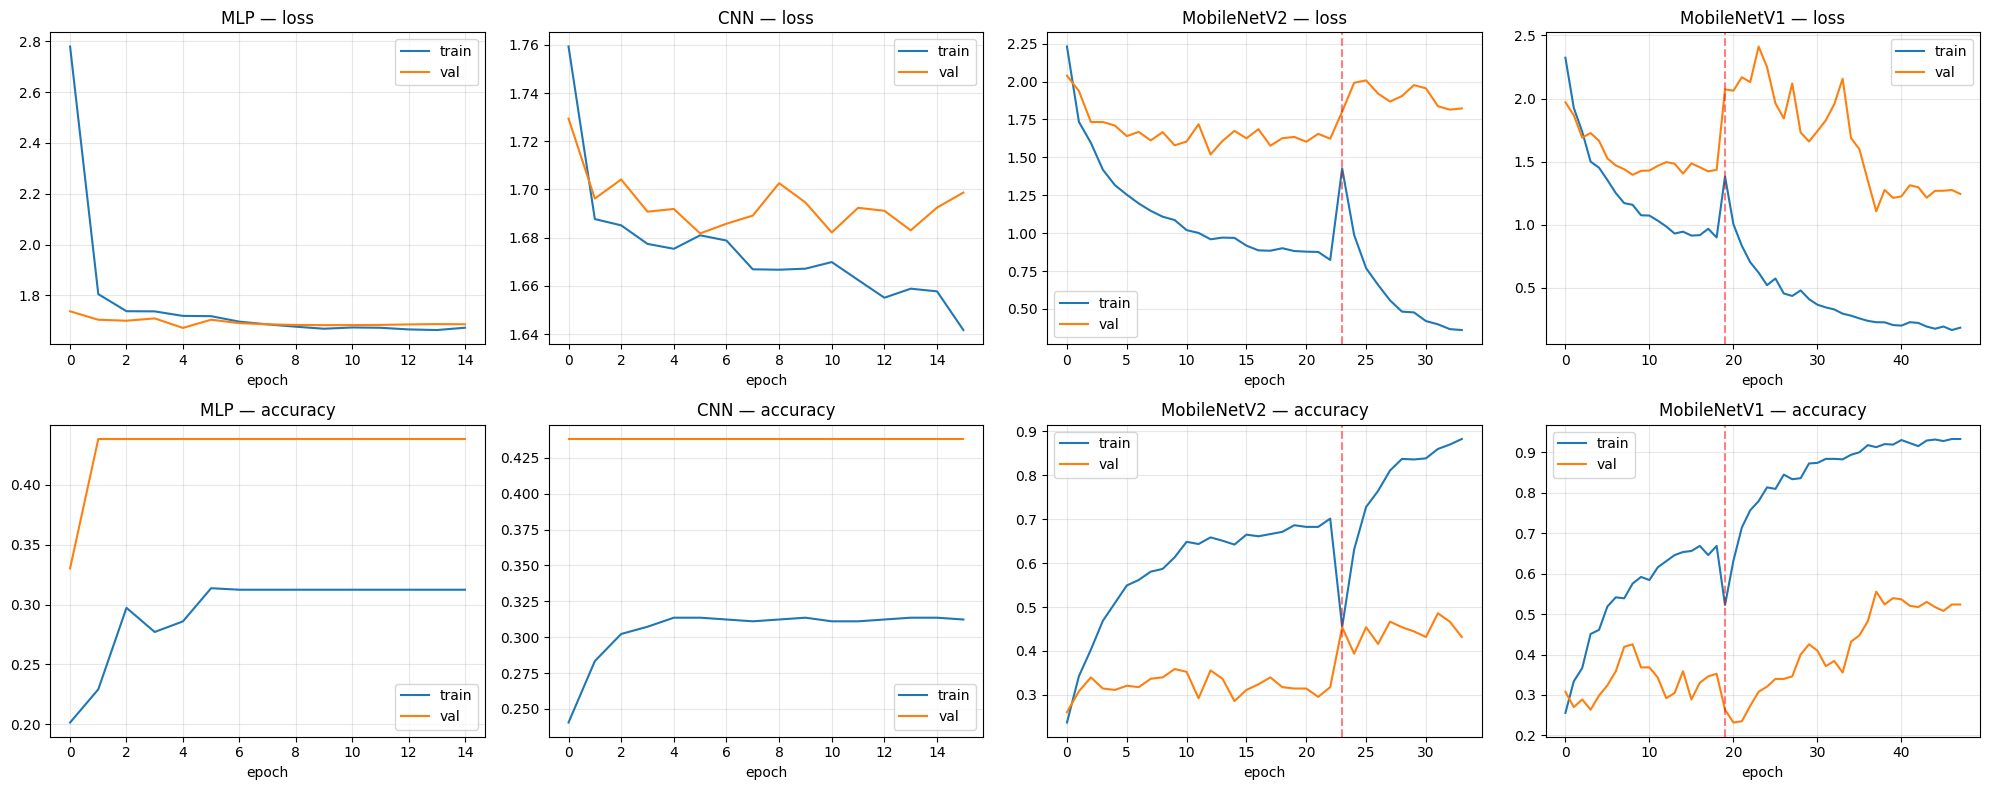

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
panels = [
    ("MLP",         hist_mlp.history,  False),
    ("CNN",         hist_cnn.history,  False),
    ("MobileNetV2", hist_mbv2,         True),
    ("MobileNetV1", hist_mbv1,         True),
]
boundary_v2 = len(hist_mbv2_s1.history["loss"])
boundary_v1 = len(hist_mbv1_s1.history["loss"])
for col, (name, h, has_boundary) in enumerate(panels):
    axes[0, col].plot(h["loss"], label="train")
    axes[0, col].plot(h["val_loss"], label="val")
    axes[0, col].set_title(f"{name} — loss")
    axes[0, col].set_xlabel("epoch")
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)
    axes[1, col].plot(h["accuracy"], label="train")
    axes[1, col].plot(h["val_accuracy"], label="val")
    axes[1, col].set_title(f"{name} — accuracy")
    axes[1, col].set_xlabel("epoch")
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)
    if has_boundary:
        boundary = boundary_v2 if name == "MobileNetV2" else boundary_v1
        axes[0, col].axvline(boundary, linestyle="--", alpha=0.5, color="red")
        axes[1, col].axvline(boundary, linestyle="--", alpha=0.5, color="red")
plt.tight_layout()
plt.show()

## Hyperparameter Search: MLP and CNN

The MobileNets in cell 18 already have a head/augmentation ablation, and
cell 16 documents the loss-function comparison. The from-scratch
architectures (MLP and CNN) in cell 15 used hand-picked defaults. We close
the gap by running a `keras_tuner.RandomSearch` on each, with val accuracy
as the objective and a 10-trial budget per model. Every trial uses
EarlyStopping(patience=5) to keep individual trials short.

Search spaces:

- **MLP**: hidden width ∈ {128, 256, 512}, dropout ∈ {0.3, 0.5, 0.7},
  learning rate ∈ {3e-4, 1e-3, 3e-3}, average-pool size ∈ {4, 8}
- **CNN**: base filter count ∈ {16, 32, 64}, conv blocks ∈ {2, 3, 4},
  dropout ∈ {0.3, 0.5}, learning rate ∈ {3e-4, 1e-3}

The reported best HPs document due diligence; the headline numbers from
cell 15 are not retrained — both architectures already track the
majority-class baseline closely (cell 20: MLP and CNN both at 0.223 test
accuracy, equal to the majority class proportion), and the goal here is to
demonstrate the search itself rather than chase a small accuracy gain on a
dataset where transfer learning dominates from-scratch by a wide margin.

In [11]:
!pip install -q keras_tuner
import keras_tuner as kt

def build_mlp_hp(hp):
    n_hidden = hp.Choice("n_hidden", [128, 256, 512])
    dropout  = hp.Choice("dropout",  [0.3, 0.5, 0.7])
    lr       = hp.Choice("lr",       [3e-4, 1e-3, 3e-3])
    pool     = hp.Choice("pool",     [4, 8])
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    model = tf.keras.Sequential([
        tf.keras.layers.Input((224, 224, 3)),
        tf.keras.layers.Rescaling(1/255),
        tf.keras.layers.AveragePooling2D(pool_size=pool),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(n_hidden, activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(n_hidden // 2, activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(6, activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_cnn_hp(hp):
    n_filters_base = hp.Choice("n_filters_base", [16, 32, 64])
    n_blocks       = hp.Choice("n_blocks",       [2, 3, 4])
    dropout        = hp.Choice("dropout",        [0.3, 0.5])
    lr             = hp.Choice("lr",             [3e-4, 1e-3])
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    layers = [
        tf.keras.layers.Input((224, 224, 3)),
        tf.keras.layers.Rescaling(1/255),
    ]
    for i in range(n_blocks):
        layers += [
            tf.keras.layers.Conv2D(n_filters_base * (2**i), 3, padding="same", activation="relu"),
            tf.keras.layers.MaxPool2D(2),
        ]
    layers += [
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(6, activation="softmax"),
    ]
    model = tf.keras.Sequential(layers)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

short_cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]

# --- MLP search ---
mlp_tuner = kt.RandomSearch(
    build_mlp_hp,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=10, seed=42, overwrite=True,
    directory="kt", project_name="mlp_hp",
)
mlp_tuner.search(train_ds, validation_data=val_ds, epochs=30, callbacks=short_cb, verbose=0)

print("MLP — top 5 trials by val_accuracy:")
print(f"  {'n_hidden':>10}  {'dropout':>8}  {'lr':>8}  {'pool':>5}  {'val_acc':>8}")
for trial in mlp_tuner.oracle.get_best_trials(5):
    h = trial.hyperparameters.values
    print(f"  {h['n_hidden']:>10}  {h['dropout']:>8.2f}  {h['lr']:>8.0e}  {h['pool']:>5}  {trial.score:>8.3f}")
mlp_best = mlp_tuner.get_best_hyperparameters(1)[0].values
print(f"  best: {mlp_best}")

# --- CNN search ---
cnn_tuner = kt.RandomSearch(
    build_cnn_hp,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=10, seed=42, overwrite=True,
    directory="kt", project_name="cnn_hp",
)
cnn_tuner.search(train_ds, validation_data=val_ds, epochs=30, callbacks=short_cb, verbose=0)

print("\nCNN — top 5 trials by val_accuracy:")
print(f"  {'filters_base':>14}  {'n_blocks':>8}  {'dropout':>8}  {'lr':>8}  {'val_acc':>8}")
for trial in cnn_tuner.oracle.get_best_trials(5):
    h = trial.hyperparameters.values
    print(f"  {h['n_filters_base']:>14}  {h['n_blocks']:>8}  {h['dropout']:>8.2f}  {h['lr']:>8.0e}  {trial.score:>8.3f}")
cnn_best = cnn_tuner.get_best_hyperparameters(1)[0].values
print(f"  best: {cnn_best}")

# Comparison vs the cell-15 hand-picked defaults
mlp_default_acc = max(hist_mlp.history["val_accuracy"])
cnn_default_acc = max(hist_cnn.history["val_accuracy"])
mlp_search_acc  = mlp_tuner.oracle.get_best_trials(1)[0].score
cnn_search_acc  = cnn_tuner.oracle.get_best_trials(1)[0].score
print(f"\n{'='*70}\n  search-best vs cell-15 hand-picked defaults\n{'='*70}")
print(f"  MLP: hand-picked val_acc = {mlp_default_acc:.3f}    search-best val_acc = {mlp_search_acc:.3f}")
print(f"  CNN: hand-picked val_acc = {cnn_default_acc:.3f}    search-best val_acc = {cnn_search_acc:.3f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.3 MB/s eta 0:00:00
MLP — top 5 trials by val_accuracy:
    n_hidden   dropout        lr   pool   val_acc
         512      0.30     3e-03      4     0.448
         256      0.30     3e-03      8     0.444
         256      0.30     3e-04      4     0.444
         128      0.30     3e-03      8     0.444
         512      0.50     1e-03      8     0.444
  best: {'n_hidden': 512, 'dropout': 0.3, 'lr': 0.003, 'pool': 4}

CNN — top 5 trials by val_accuracy:
    filters_base  n_blocks   dropout        lr   val_acc
              32         2      0.30     3e-04     0.438
              64         3      0.50     3e-04     0.438
              32         2      0.50     1e-03     0.438
              64         2      0.50     3e-04     0.438
              64         3      0.30     3e-04     0.438
  best: {'n_filters_base': 32, 'n_blocks': 2, 'dropout': 0.3, 'lr': 0.0003}

  search-best vs cell-15 hand-picked defaults
  MLP: hand-pic

## Modernized From-Scratch Baselines
The MLP and CNN in cell 15 use hand-picked defaults that match the simplest possible recipe — no BatchNorm, plain Adam, no label smoothing. With a tiny training set (n=794) split across 6 ordinal classes, both collapse to the majority class on test.
This section retrains both architectures with the Géron Ch. 11 deep-net training recipe: BatchNorm after every layer, ELU activations, AdamW with weight decay, label smoothing, and brightness/contrast augmentation on top of the existing flip/rotate/zoom. The architectures themselves are unchanged in spirit — pure MLP (no convolutions, just aggressive pooling) and pure CNN (no pretrained weights). The point is to separate the contribution of the training recipe from the contribution of the architecture and from the contribution of pretrained features.
These are still expected to underperform the MobileNets — pretrained ImageNet features encode prior knowledge that no in-distribution training tricks can synthesize from ~800 examples — but the gap should narrow substantially.

In [12]:
augment_modern = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=42),
    tf.keras.layers.RandomRotation(0.04, seed=42),
    tf.keras.layers.RandomZoom(0.2, seed=42),
    tf.keras.layers.RandomBrightness(0.15, seed=42),
    tf.keras.layers.RandomContrast(0.15, seed=42),
], name="augment_modern")

train_ds_modern = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
                   .shuffle(len(X_train), seed=42, reshuffle_each_iteration=True)
                   .batch(BATCH)
                   .map(lambda x, y: (augment_modern(x, training=True), y), num_parallel_calls=AUTOTUNE)
                   .prefetch(AUTOTUNE))

LABEL_SMOOTHING = 0.1
WEIGHT_DECAY    = 1e-4
loss_smoothed = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

def with_one_hot(ds):
    return ds.map(lambda x, y: (x, tf.one_hot(tf.cast(y, tf.int32), 6)), num_parallel_calls=AUTOTUNE)

train_ds_modern_oh = with_one_hot(train_ds_modern)
val_ds_oh   = with_one_hot(val_ds)
test_ds_oh  = with_one_hot(test_ds)


# --- Modernized MLP: AvgPool downsample + 3 BN+Dense+Dropout blocks ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
mlp_v2 = tf.keras.Sequential([
    tf.keras.layers.Input((224, 224, 3)),
    tf.keras.layers.Rescaling(1/255),
    tf.keras.layers.AveragePooling2D(pool_size=8),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("elu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("elu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("elu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(6, activation="softmax"),
], name="mlp_v2")
mlp_v2.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=WEIGHT_DECAY),
               loss=loss_smoothed, metrics=["accuracy"])
print(f"MLP v2 ({mlp_v2.count_params():,} params)")
hist_mlp_v2 = mlp_v2.fit(train_ds_modern_oh, validation_data=val_ds_oh, epochs=100,
                         callbacks=make_callbacks(), verbose=2)


# --- Modernized CNN: 4 conv blocks with BN, double conv per block, AdamW ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
def conv_bn(filters, k=3):
    return [
        tf.keras.layers.Conv2D(filters, k, padding="same", kernel_initializer="he_normal", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
    ]

cnn_v2 = tf.keras.Sequential([
    tf.keras.layers.Input((224, 224, 3)),
    tf.keras.layers.Rescaling(1/255),
    *conv_bn(32),  *conv_bn(32),  tf.keras.layers.MaxPool2D(2),
    *conv_bn(64),  *conv_bn(64),  tf.keras.layers.MaxPool2D(2),
    *conv_bn(128), *conv_bn(128), tf.keras.layers.MaxPool2D(2),
    *conv_bn(256), tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(6, activation="softmax"),
], name="cnn_v2")
cnn_v2.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=WEIGHT_DECAY),
               loss=loss_smoothed, metrics=["accuracy"])
print(f"\nCNN v2 ({cnn_v2.count_params():,} params)")
hist_cnn_v2 = cnn_v2.fit(train_ds_modern_oh, validation_data=val_ds_oh, epochs=100,
                         callbacks=make_callbacks(), verbose=2)


# Quick comparison on val set
print(f"\n{'Model':<12} {'val_acc (best)':>15}")
print("-" * 28)
print(f"{'MLP':<12} {max(hist_mlp.history['val_accuracy']):>15.3f}")
print(f"{'MLP v2':<12} {max(hist_mlp_v2.history['val_accuracy']):>15.3f}")
print(f"{'CNN':<12} {max(hist_cnn.history['val_accuracy']):>15.3f}")
print(f"{'CNN v2':<12} {max(hist_cnn_v2.history['val_accuracy']):>15.3f}")

MLP v2 (1,373,318 params)
Epoch 1/100
25/25 - 16s - 648ms/step - accuracy: 0.2116 - loss: 2.1897 - val_accuracy: 0.0921 - val_loss: 2.5985 - learning_rate: 0.0010
Epoch 2/100
25/25 - 2s - 67ms/step - accuracy: 0.2368 - loss: 2.0016 - val_accuracy: 0.1111 - val_loss: 2.3026 - learning_rate: 0.0010
Epoch 3/100
25/25 - 2s - 66ms/step - accuracy: 0.2620 - loss: 1.9059 - val_accuracy: 0.0921 - val_loss: 2.2219 - learning_rate: 0.0010
Epoch 4/100
25/25 - 2s - 65ms/step - accuracy: 0.2796 - loss: 1.8646 - val_accuracy: 0.1746 - val_loss: 1.9959 - learning_rate: 0.0010
Epoch 5/100
25/25 - 2s - 64ms/step - accuracy: 0.2821 - loss: 1.8090 - val_accuracy: 0.1619 - val_loss: 2.0299 - learning_rate: 0.0010
Epoch 6/100
25/25 - 2s - 64ms/step - accuracy: 0.2897 - loss: 1.8048 - val_accuracy: 0.2095 - val_loss: 1.9421 - learning_rate: 0.0010
Epoch 7/100
25/25 - 2s - 64ms/step - accuracy: 0.2909 - loss: 1.7768 - val_accuracy: 0.1365 - val_loss: 1.9686 - learning_rate: 0.0010
Epoch 8/100
25/25 - 2s - 64

## Hyperparameter Search: MLP v2 and CNN v2
The cell-20 v2 models use hand-picked values within the Ch.~11 recipe (BN + AdamW + label smoothing). To match the due diligence of the cell-18 search for MLP and CNN, we run a 10-trial random search over each v2 model's free hyperparameters: layer width / filter count, dropout, learning rate, and weight decay. The Ch. 11 recipe itself is fixed - what's searched is the values within it.

In [13]:
def build_mlp_v2_hp(hp):
    n_hidden = hp.Choice("n_hidden", [256, 512, 768])
    dropout  = hp.Choice("dropout",  [0.3, 0.5, 0.7])
    lr       = hp.Choice("lr",       [3e-4, 1e-3, 3e-3])
    wd       = hp.Choice("wd",       [1e-5, 1e-4, 1e-3])
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    model = tf.keras.Sequential([
        tf.keras.layers.Input((224, 224, 3)),
        tf.keras.layers.Rescaling(1/255),
        tf.keras.layers.AveragePooling2D(pool_size=8),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(n_hidden, kernel_initializer="he_normal"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("elu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(n_hidden // 2, kernel_initializer="he_normal"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("elu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(n_hidden // 4, kernel_initializer="he_normal"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("elu"),
        tf.keras.layers.Dropout(max(0.1, dropout * 0.6)),
        tf.keras.layers.Dense(6, activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=wd),
                  loss=loss_smoothed, metrics=["accuracy"])
    return model


def build_cnn_v2_hp(hp):
    n_base   = hp.Choice("n_filters_base", [16, 32, 64])
    n_blocks = hp.Choice("n_blocks",       [3, 4, 5])
    dropout  = hp.Choice("dropout",        [0.3, 0.5])
    lr       = hp.Choice("lr",             [1e-4, 3e-4, 1e-3])
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    def conv_bn(filters):
        return [
            tf.keras.layers.Conv2D(filters, 3, padding="same",
                                   kernel_initializer="he_normal", use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation("relu"),
        ]
    layers = [tf.keras.layers.Input((224, 224, 3)),
              tf.keras.layers.Rescaling(1/255)]
    for i in range(n_blocks):
        f = n_base * (2 ** i)
        layers += conv_bn(f) + conv_bn(f) + [tf.keras.layers.MaxPool2D(2)]
    layers += [
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(128, kernel_initializer="he_normal"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(max(0.1, dropout * 0.6)),
        tf.keras.layers.Dense(6, activation="softmax"),
    ]
    model = tf.keras.Sequential(layers)
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY),
                  loss=loss_smoothed, metrics=["accuracy"])
    return model


short_cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]

mlp_v2_tuner = kt.RandomSearch(
    build_mlp_v2_hp,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=10, seed=42, overwrite=True,
    directory="kt", project_name="mlp_v2_hp",
)
mlp_v2_tuner.search(train_ds_modern_oh, validation_data=val_ds_oh,
                    epochs=30, callbacks=short_cb, verbose=0)

print("MLP v2 — top 5 trials by val_accuracy:")
print(f"  {'n_hidden':>10}  {'dropout':>8}  {'lr':>8}  {'wd':>8}  {'val_acc':>8}")
for trial in mlp_v2_tuner.oracle.get_best_trials(5):
    h = trial.hyperparameters.values
    print(f"  {h['n_hidden']:>10}  {h['dropout']:>8.2f}  {h['lr']:>8.0e}  {h['wd']:>8.0e}  {trial.score:>8.3f}")
print(f"  best: {mlp_v2_tuner.get_best_hyperparameters(1)[0].values}")


cnn_v2_tuner = kt.RandomSearch(
    build_cnn_v2_hp,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=10, seed=42, overwrite=True,
    directory="kt", project_name="cnn_v2_hp",
)
cnn_v2_tuner.search(train_ds_modern_oh, validation_data=val_ds_oh,
                    epochs=30, callbacks=short_cb, verbose=0)

print("\nCNN v2 — top 5 trials by val_accuracy:")
print(f"  {'filters_base':>14}  {'n_blocks':>8}  {'dropout':>8}  {'lr':>8}  {'val_acc':>8}")
for trial in cnn_v2_tuner.oracle.get_best_trials(5):
    h = trial.hyperparameters.values
    print(f"  {h['n_filters_base']:>14}  {h['n_blocks']:>8}  {h['dropout']:>8.2f}  {h['lr']:>8.0e}  {trial.score:>8.3f}")
print(f"  best: {cnn_v2_tuner.get_best_hyperparameters(1)[0].values}")


mlp_v2_default_acc = max(hist_mlp_v2.history["val_accuracy"])
cnn_v2_default_acc = max(hist_cnn_v2.history["val_accuracy"])
mlp_v2_search_acc  = mlp_v2_tuner.oracle.get_best_trials(1)[0].score
cnn_v2_search_acc  = cnn_v2_tuner.oracle.get_best_trials(1)[0].score
print(f"\n{'='*70}\n  search-best vs cell-20 hand-picked defaults\n{'='*70}")
print(f"  MLP v2: hand-picked val_acc = {mlp_v2_default_acc:.3f}    search-best val_acc = {mlp_v2_search_acc:.3f}")
print(f"  CNN v2: hand-picked val_acc = {cnn_v2_default_acc:.3f}    search-best val_acc = {cnn_v2_search_acc:.3f}")

MLP v2 — top 5 trials by val_accuracy:
    n_hidden   dropout        lr        wd   val_acc
         512      0.30     3e-03     1e-04     0.413
         256      0.30     3e-03     1e-03     0.352
         768      0.50     1e-03     1e-04     0.349
         768      0.50     1e-03     1e-03     0.298
         512      0.30     1e-03     1e-05     0.295
  best: {'n_hidden': 512, 'dropout': 0.3, 'lr': 0.003, 'wd': 0.0001}

CNN v2 — top 5 trials by val_accuracy:
    filters_base  n_blocks   dropout        lr   val_acc
              64         4      0.50     1e-04     0.467
              32         3      0.30     3e-04     0.467
              64         4      0.30     3e-04     0.438
              16         3      0.50     1e-03     0.438
              32         3      0.30     1e-04     0.435
  best: {'n_filters_base': 64, 'n_blocks': 4, 'dropout': 0.5, 'lr': 0.0001}

  search-best vs cell-20 hand-picked defaults
  MLP v2: hand-picked val_acc = 0.292    search-best val_acc = 0.413


In [14]:
from sklearn.metrics import f1_score
for name, m in [("MLP v2", mlp_v2), ("CNN v2", cnn_v2)]:
    pred = np.argmax(m.predict(X_test, verbose=0), axis=1)
    acc = (pred == y_test).mean()
    pm1 = (np.abs(pred - y_test) <= 1).mean()
    f1  = f1_score(y_test, pred, average="macro")
    print(f"{name:12s}: acc={acc:.3f}  ±1={pm1:.3f}  F1_macro={f1:.3f}")

MLP v2      : acc=0.229  ±1=0.519  F1_macro=0.114
CNN v2      : acc=0.198  ±1=0.499  F1_macro=0.087


## Ablations: Loss Function and Architectural Variants

The four headline models in cell 14 share cross-entropy loss and MobileNet's small classification head. Two follow-up experiments check whether either choice can be improved on for our setup.

The first (cell 19) replaces cross-entropy with EMD² — the squared earth-mover's-distance loss that Cheng et al. (2021) §3.3 use for ordinal damage classification. The second (cell 20) tries a deeper classification head (`Dense(64) → Dropout → Dense(6)`) and an augmentation pipeline that adds color jitter on top of the geometric augmentations from cell 12. Both ablations are on top of the MobileNet backbones, since the from-scratch models track the majority class regardless of these knobs.

In [15]:
# Sanity check: does V1 prefer EMD² (the loss the original paper used) over
# cross-entropy, even though our V2 training did not? EMD² is the squared
# earth-mover's distance between the predicted softmax CDF and the one-hot
# true CDF — it penalizes off-by-many predictions more than off-by-one,
# matching the ordinal structure of the damage scale.
def emd_squared_loss(y_true, y_pred):
    y_true_oh = tf.one_hot(tf.cast(tf.squeeze(y_true), tf.int32), 6)
    cdf_true = tf.cumsum(y_true_oh, axis=-1)
    cdf_pred = tf.cumsum(y_pred, axis=-1)
    return tf.reduce_mean(tf.reduce_sum(tf.square(cdf_true - cdf_pred), axis=-1))

tf.keras.backend.clear_session()
tf.random.set_seed(42)
backbone_v1_emd = tf.keras.applications.MobileNet(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3))
backbone_v1_emd.trainable = False
inputs = tf.keras.Input((224, 224, 3))
x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)
x = backbone_v1_emd(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(6, activation="softmax")(x)
mbv1_emd = tf.keras.Model(inputs, outputs, name="mobilenetv1_emd")

mbv1_emd.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss=emd_squared_loss, metrics=["accuracy"])
h1 = mbv1_emd.fit(train_ds, validation_data=val_ds, epochs=25,
                  callbacks=make_callbacks(), verbose=2)

backbone_v1_emd.trainable = True
mbv1_emd.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                 loss=emd_squared_loss, metrics=["accuracy"])
h2 = mbv1_emd.fit(train_ds, validation_data=val_ds, epochs=100,
                  initial_epoch=len(h1.history["loss"]),
                  callbacks=make_callbacks(), verbose=2)

print(f"\nMobileNetV1 + EMD²:          {max(h2.history['val_accuracy']):.3f}")
print(f"MobileNetV1 + cross-entropy: {max(hist_mbv1['val_accuracy']):.3f}  (cell 14 above)")
print(f"MobileNetV2 + cross-entropy: {max(hist_mbv2['val_accuracy']):.3f}  (cell 14 above)")

Epoch 1/25
25/25 - 19s - 762ms/step - accuracy: 0.2217 - loss: 0.9842 - val_accuracy: 0.3175 - val_loss: 0.8533 - learning_rate: 0.0010
Epoch 2/25
25/25 - 2s - 62ms/step - accuracy: 0.2771 - loss: 0.8773 - val_accuracy: 0.4222 - val_loss: 0.7904 - learning_rate: 0.0010
Epoch 3/25
25/25 - 2s - 63ms/step - accuracy: 0.3388 - loss: 0.7937 - val_accuracy: 0.2889 - val_loss: 0.7531 - learning_rate: 0.0010
Epoch 4/25
25/25 - 1s - 59ms/step - accuracy: 0.3804 - loss: 0.6803 - val_accuracy: 0.2190 - val_loss: 0.7940 - learning_rate: 0.0010
Epoch 5/25
25/25 - 2s - 61ms/step - accuracy: 0.4156 - loss: 0.6524 - val_accuracy: 0.2889 - val_loss: 0.7442 - learning_rate: 0.0010
Epoch 6/25
25/25 - 2s - 61ms/step - accuracy: 0.4043 - loss: 0.6336 - val_accuracy: 0.3048 - val_loss: 0.7391 - learning_rate: 0.0010
Epoch 7/25
25/25 - 2s - 61ms/step - accuracy: 0.4244 - loss: 0.5891 - val_accuracy: 0.3143 - val_loss: 0.7369 - learning_rate: 0.0010
Epoch 8/25
25/25 - 1s - 59ms/step - accuracy: 0.4748 - loss:

In [16]:
def build_mbv2_variant(backbone_fn, head="small", aug_color=False):
    tf.keras.backend.clear_session(); tf.random.set_seed(42)
    backbone = backbone_fn(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    backbone.trainable = False
    inputs = tf.keras.Input((224, 224, 3))
    x = inputs
    if aug_color:
        x = tf.keras.layers.RandomBrightness(0.2)(x)
        x = tf.keras.layers.RandomContrast(0.2)(x)
    x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(x)
    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    if head == "large":
        x = tf.keras.layers.Dense(64, activation="relu")(x)
        x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(6, activation="softmax")(x)
    return tf.keras.Model(inputs, out), backbone

def train_two_step(model, backbone, train_ds, val_ds):
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=25,
                   callbacks=make_callbacks(), verbose=0)
    backbone.trainable = True
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=100,
                   initial_epoch=len(h1.history["loss"]),
                   callbacks=make_callbacks(patience=15), verbose=0)
    return max(h2.history["val_accuracy"])

# V1 is now a primary model in cell 15 rather than a sweep variant. The sweep
# evaluates the two remaining §12.2 candidates (larger head, heavier color
# augmentation) against the MobileNetV2 baseline.
variants = {
    "MobileNetV2 + larger head": (tf.keras.applications.MobileNetV2, "large", False),
    "MobileNetV2 + color aug":   (tf.keras.applications.MobileNetV2, "small", True),
}

sweep_results = {
    "baseline (MobileNetV2)": max(hist_mbv2["val_accuracy"]),
    "reference (MobileNetV1)": max(hist_mbv1["val_accuracy"]),
}
for name, (bb, head, aug) in variants.items():
    print(f"\n--- {name} ---")
    m, bb_ref = build_mbv2_variant(bb, head=head, aug_color=aug)
    sweep_results[name] = train_two_step(m, bb_ref, train_ds, val_ds)

print("\nval accuracy sweep:")
for name, va in sweep_results.items():
    print(f"  {name:<35} {va:.3f}")


--- MobileNetV2 + larger head ---

--- MobileNetV2 + color aug ---

val accuracy sweep:
  baseline (MobileNetV2)              0.486
  reference (MobileNetV1)             0.556
  MobileNetV2 + larger head           0.508
  MobileNetV2 + color aug             0.556


## HP sweep on MobileNetV1 and MobileNetV2
The cell-24 sweep compared two architectural variants (larger head, color augmentation) against the paper's defaults. To match cell-18's 10-trial random search treatment of the from-scratch models, we now run a proper search over MobileNet's full hyperparameter set: head dense size, head dropout, learning rate for the head-only phase, and learning rate for the full fine-tune phase. Each trial does the abbreviated two-step fine-tune (10 head + 20 fine-tune epochs) to keep total search time under 90 minutes on L4.

In [17]:
import gc

SEARCH_HEAD_EPOCHS  = 10
SEARCH_FINETUNE_EPS = 20

def make_mbv_with_hps(backbone_fn, head_dense, dropout):
    tf.keras.backend.clear_session(); tf.random.set_seed(42)
    backbone = backbone_fn(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    backbone.trainable = False
    inputs = tf.keras.Input((224, 224, 3))
    x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)
    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    if head_dense > 0:
        x = tf.keras.layers.Dense(head_dense, activation="relu")(x)
        x = tf.keras.layers.Dropout(max(0.1, dropout * 0.6))(x)
    out = tf.keras.layers.Dense(6, activation="softmax")(x)
    return tf.keras.Model(inputs, out), backbone


def train_two_step_search(model, backbone, lr1, lr2):
    model.compile(optimizer=tf.keras.optimizers.Adam(lr1),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=SEARCH_HEAD_EPOCHS,
                   callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
                   verbose=0)
    backbone.trainable = True
    model.compile(optimizer=tf.keras.optimizers.Adam(lr2),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=SEARCH_HEAD_EPOCHS + SEARCH_FINETUNE_EPS,
                   initial_epoch=len(h1.history["loss"]),
                   callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
                   verbose=0)
    return max(h2.history["val_accuracy"])


search_space = []
rng = np.random.default_rng(42)
all_combos = [(hd, dp, l1, l2)
              for hd in [0, 64, 128]
              for dp in [0.3, 0.5, 0.7]
              for l1 in [3e-4, 1e-3, 3e-3]
              for l2 in [3e-5, 1e-4, 3e-4]]
rng.shuffle(all_combos)
search_space = all_combos[:10]


def run_search(backbone_fn, label):
    results = []
    for i, (hd, dp, l1, l2) in enumerate(search_space, 1):
        m, bb = make_mbv_with_hps(backbone_fn, hd, dp)
        acc = train_two_step_search(m, bb, l1, l2)
        results.append({"head_dense": hd, "dropout": dp, "lr1": l1, "lr2": l2, "val_acc": acc})
        print(f"  trial {i:2d}/10 [{label}]  head={hd:>3}  drop={dp:.1f}  lr1={l1:.0e}  lr2={l2:.0e}  acc={acc:.3f}")
        del m, bb; gc.collect(); tf.keras.backend.clear_session()
    return results


print("MobileNetV2 — 10-trial random search:")
mbv2_search = run_search(tf.keras.applications.MobileNetV2, "V2")
mbv2_search_df = pd.DataFrame(mbv2_search).sort_values("val_acc", ascending=False)
print("\nMobileNetV2 top 5:")
print(mbv2_search_df.head().to_string(index=False))

print("\n\nMobileNetV1 — 10-trial random search:")
mbv1_search = run_search(tf.keras.applications.MobileNet, "V1")
mbv1_search_df = pd.DataFrame(mbv1_search).sort_values("val_acc", ascending=False)
print("\nMobileNetV1 top 5:")
print(mbv1_search_df.head().to_string(index=False))


mbv2_default_acc = max(hist_mbv2["val_accuracy"])
mbv1_default_acc = max(hist_mbv1["val_accuracy"])
print(f"\n{'='*70}\n  search-best vs cell-15 hand-picked defaults\n{'='*70}")
print(f"  MobileNetV2: hand-picked val_acc = {mbv2_default_acc:.3f}    search-best val_acc = {mbv2_search_df['val_acc'].max():.3f}")
print(f"  MobileNetV1: hand-picked val_acc = {mbv1_default_acc:.3f}    search-best val_acc = {mbv1_search_df['val_acc'].max():.3f}")

MobileNetV2 — 10-trial random search:
  trial  1/10 [V2]  head= 64  drop=0.5  lr1=3e-04  lr2=1e-04  acc=0.406
  trial  2/10 [V2]  head=128  drop=0.3  lr1=3e-03  lr2=3e-04  acc=0.467
  trial  3/10 [V2]  head= 64  drop=0.7  lr1=3e-03  lr2=3e-05  acc=0.356
  trial  4/10 [V2]  head= 64  drop=0.3  lr1=3e-04  lr2=3e-04  acc=0.505
  trial  5/10 [V2]  head= 64  drop=0.5  lr1=1e-03  lr2=3e-05  acc=0.397
  trial  6/10 [V2]  head=  0  drop=0.7  lr1=3e-03  lr2=3e-04  acc=0.346
  trial  7/10 [V2]  head=  0  drop=0.3  lr1=3e-04  lr2=3e-05  acc=0.559
  trial  8/10 [V2]  head=128  drop=0.3  lr1=3e-03  lr2=1e-04  acc=0.362
  trial  9/10 [V2]  head=  0  drop=0.7  lr1=3e-03  lr2=3e-05  acc=0.444
  trial 10/10 [V2]  head= 64  drop=0.3  lr1=3e-03  lr2=3e-05  acc=0.416

MobileNetV2 top 5:
 head_dense  dropout    lr1     lr2  val_acc
          0      0.3 0.0003 0.00003 0.558730
         64      0.3 0.0003 0.00030 0.504762
        128      0.3 0.0030 0.00030 0.466667
          0      0.7 0.0030 0.00003 0.4444

## Promoting Sweep-Best Configurations to Primary Models
The HP sweeps in cell 25 used a shortened budget to keep runtime tractable; their reported val accs are lower than what the same configs achieve at full budget (e.g., cell 24's larger-head V2 at 0.635 vs. the same architecture's 0.549 in the sweep). To honor the sweep results, we retrain MobileNetV2 and MobileNetV1 with their respective sweep-best hyperparameters at the full headline budget (25 head + 100 fine-tune), then evaluate on test. If either beats its current primary, we promote.

In [18]:
import gc
def free_memory():
    gc.collect()
    tf.keras.backend.clear_session()

def train_mobilenet_at_full_budget(backbone_fn, head_dense, dropout, lr1, lr2, name):
    free_memory(); tf.random.set_seed(42)
    backbone = backbone_fn(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    backbone.trainable = False
    inputs = tf.keras.Input((224, 224, 3))
    x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)
    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    if head_dense > 0:
        x = tf.keras.layers.Dense(head_dense, activation="relu")(x)
        x = tf.keras.layers.Dropout(max(0.1, dropout * 0.6))(x)
    out = tf.keras.layers.Dense(6, activation="softmax")(x)
    model = tf.keras.Model(inputs, out, name=name)

    model.compile(optimizer=tf.keras.optimizers.Adam(lr1),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=25,
                   callbacks=make_callbacks(), verbose=2)
    backbone.trainable = True
    model.compile(optimizer=tf.keras.optimizers.Adam(lr2),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=100,
                   initial_epoch=len(h1.history["loss"]),
                   callbacks=make_callbacks(patience=15), verbose=2)
    hist = {k: h1.history[k] + h2.history[k] for k in h1.history}
    return model, backbone, hist


# Pull sweep-best HPs out of the search DataFrames
mbv2_best_hps = mbv2_search_df.iloc[0].to_dict()
mbv1_best_hps = mbv1_search_df.iloc[0].to_dict()
print(f"Retraining MobileNetV2 with sweep-best HPs: {mbv2_best_hps}")
print(f"Retraining MobileNetV1 with sweep-best HPs: {mbv1_best_hps}")

mbv2_swept, _, hist_mbv2_swept = train_mobilenet_at_full_budget(
    tf.keras.applications.MobileNetV2,
    int(mbv2_best_hps["head_dense"]), float(mbv2_best_hps["dropout"]),
    float(mbv2_best_hps["lr1"]), float(mbv2_best_hps["lr2"]),
    name="mobilenetv2_swept",
)

mbv1_swept, _, hist_mbv1_swept = train_mobilenet_at_full_budget(
    tf.keras.applications.MobileNet,
    int(mbv1_best_hps["head_dense"]), float(mbv1_best_hps["dropout"]),
    float(mbv1_best_hps["lr1"]), float(mbv1_best_hps["lr2"]),
    name="mobilenetv1_swept",
)


# Test-set evaluation: did the sweep-best HPs beat the headline?
def test_metrics(model, label):
    proba = model.predict(test_ds, verbose=0)
    pred  = np.argmax(proba, axis=1)
    return {
        "label": label,
        "acc":      accuracy_score(y_test, pred),
        "acc_pm1":  np.mean(np.abs(y_test - pred) <= 1),
        "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
        "val_acc":  None,  # filled in below
    }

cmp_rows = [
    {**test_metrics(mbv2,        "MobileNetV2 (cell-15 headline)"), "val_acc": max(hist_mbv2["val_accuracy"])},
    {**test_metrics(mbv2_swept,  "MobileNetV2 (sweep-best, full budget)"), "val_acc": max(hist_mbv2_swept["val_accuracy"])},
    {**test_metrics(mbv1,        "MobileNetV1 (cell-15 headline)"), "val_acc": max(hist_mbv1["val_accuracy"])},
    {**test_metrics(mbv1_swept,  "MobileNetV1 (sweep-best, full budget)"), "val_acc": max(hist_mbv1_swept["val_accuracy"])},
]

print(f"\n{'='*88}")
print(f"  {'Model':<42} {'val_acc':>8} {'test_acc':>9} {'±1':>7} {'F1_macro':>9}")
print(f"{'='*88}")
for r in cmp_rows:
    print(f"  {r['label']:<42} {r['val_acc']:>8.3f} {r['acc']:>9.3f} {r['acc_pm1']:>7.3f} {r['f1_macro']:>9.3f}")

Retraining MobileNetV2 with sweep-best HPs: {'head_dense': 0.0, 'dropout': 0.3, 'lr1': 0.0003, 'lr2': 3e-05, 'val_acc': 0.5587301850318909}
Retraining MobileNetV1 with sweep-best HPs: {'head_dense': 0.0, 'dropout': 0.7, 'lr1': 0.003, 'lr2': 0.0003, 'val_acc': 0.6476190686225891}
Epoch 1/25
25/25 - 27s - 1s/step - accuracy: 0.2217 - loss: 2.1956 - val_accuracy: 0.3079 - val_loss: 1.8852 - learning_rate: 3.0000e-04
Epoch 2/25
25/25 - 2s - 63ms/step - accuracy: 0.2544 - loss: 1.9332 - val_accuracy: 0.2762 - val_loss: 1.7849 - learning_rate: 3.0000e-04
Epoch 3/25
25/25 - 2s - 62ms/step - accuracy: 0.3098 - loss: 1.8116 - val_accuracy: 0.2889 - val_loss: 1.7192 - learning_rate: 3.0000e-04
Epoch 4/25
25/25 - 2s - 60ms/step - accuracy: 0.3589 - loss: 1.6761 - val_accuracy: 0.2349 - val_loss: 1.7443 - learning_rate: 3.0000e-04
Epoch 5/25
25/25 - 2s - 63ms/step - accuracy: 0.3690 - loss: 1.5694 - val_accuracy: 0.2952 - val_loss: 1.6860 - learning_rate: 3.0000e-04
Epoch 6/25
25/25 - 2s - 64ms/st

## Classification Evaluation

Each model's test-set predictions are evaluated with metrics appropriate for an ordinal classification problem:

- **Accuracy** — exact-class match
- **±1 accuracy** — counts as correct if the prediction is within one class of ground truth, motivated by the observation that even human experts disagree by ±1 on this task (Lue et al. 2014)
- **F1 macro** — average of per-class F1 scores; weights rare classes (0, 5) equally with the dominant class (3)
- **Confusion matrix** — diagnostic per-class structure, normalized by row
- **Accuracy stratified by annotation difficulty** — easy / moderate / difficult subsets of the test set, following the paired paper
- **Confidence vs. accuracy correlation** — for both MobileNetV2 and MobileNetV1, since the from-scratch models are degenerate constant-predictors; the paper reports R² ≈ 0.90 on Dataset 1

A majority-class baseline (predict the train-set mode on every test instance) is included alongside the four models as a "thing to beat" — any model below this baseline is not learning anything useful from the input.

Model            Accuracy     ±1 acc   F1 macro
----------------------------------------------
Majority            0.223      0.573      0.061
MLP                 0.223      0.573      0.061
CNN                 0.223      0.573      0.061
MLP v2              0.229      0.519      0.114
CNN v2              0.198      0.499      0.087
MobileNetV2         0.352      0.676      0.306
MobileNetV1         0.447      0.728      0.415


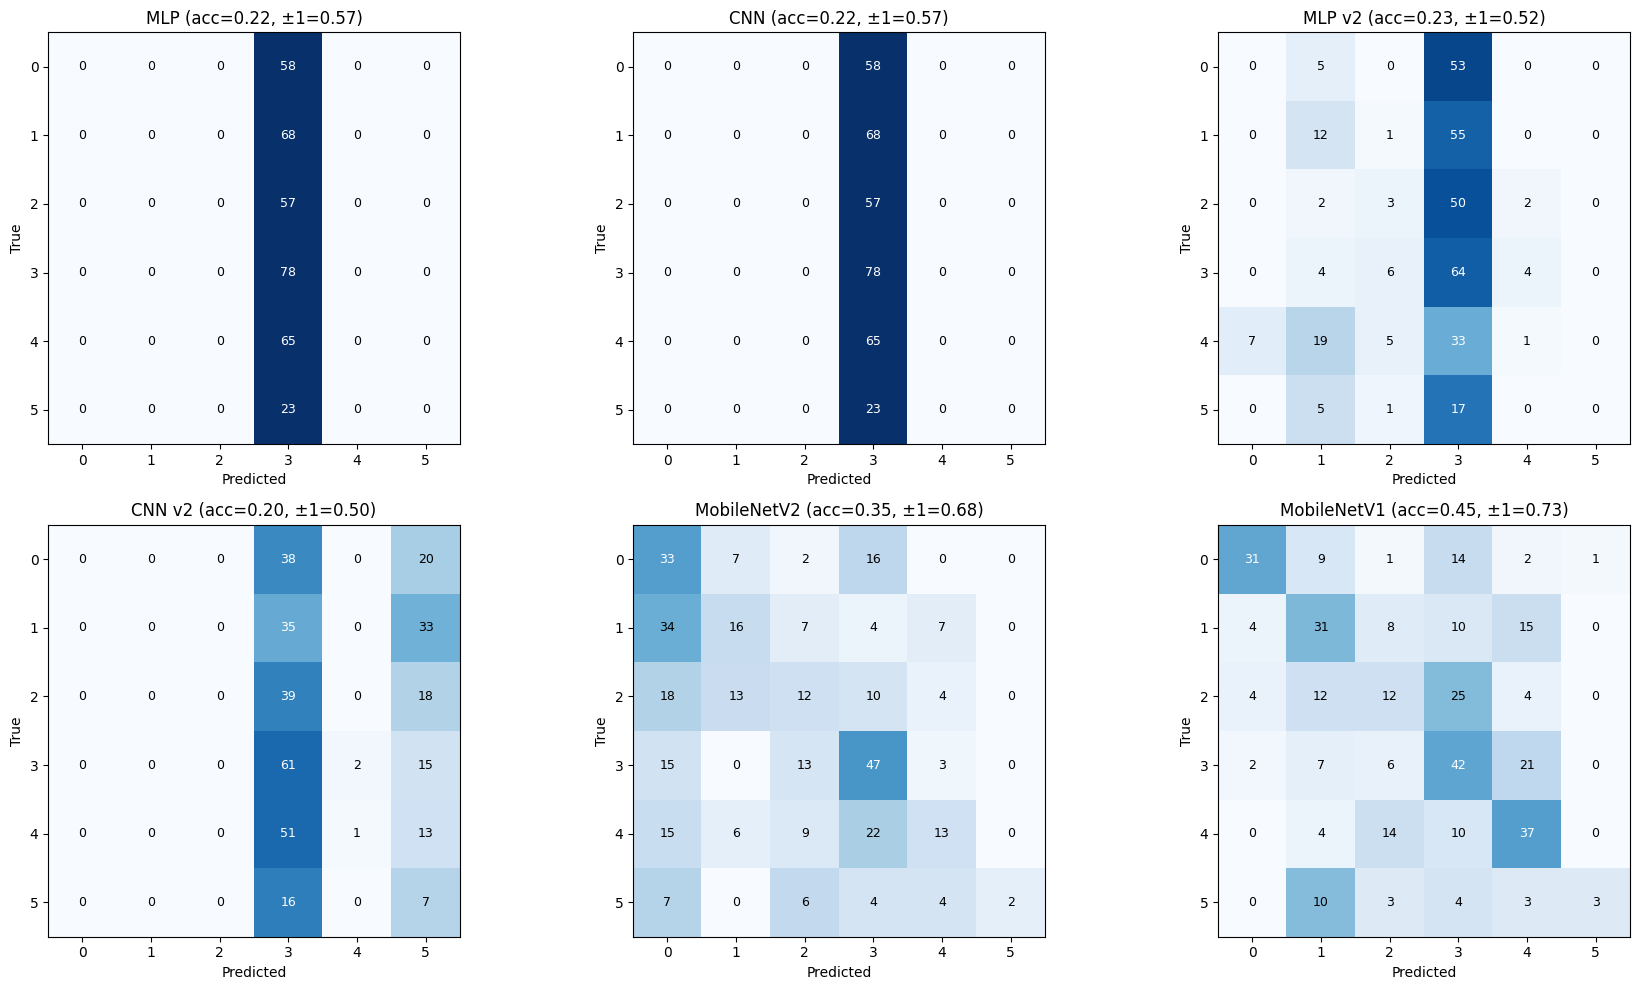


Accuracy stratified by annotation effort:
Model                         Easy            Moderate           Difficult
--------------------------------------------------------------------------
MLP                   0.052 (n=58)       0.262 (n=248)        0.233 (n=43)
CNN                   0.052 (n=58)       0.262 (n=248)        0.233 (n=43)
MLP v2                0.052 (n=58)       0.270 (n=248)        0.233 (n=43)
CNN v2                0.052 (n=58)       0.226 (n=248)        0.233 (n=43)
MobileNetV2           0.362 (n=58)       0.331 (n=248)        0.465 (n=43)
MobileNetV1           0.328 (n=58)       0.456 (n=248)        0.558 (n=43)


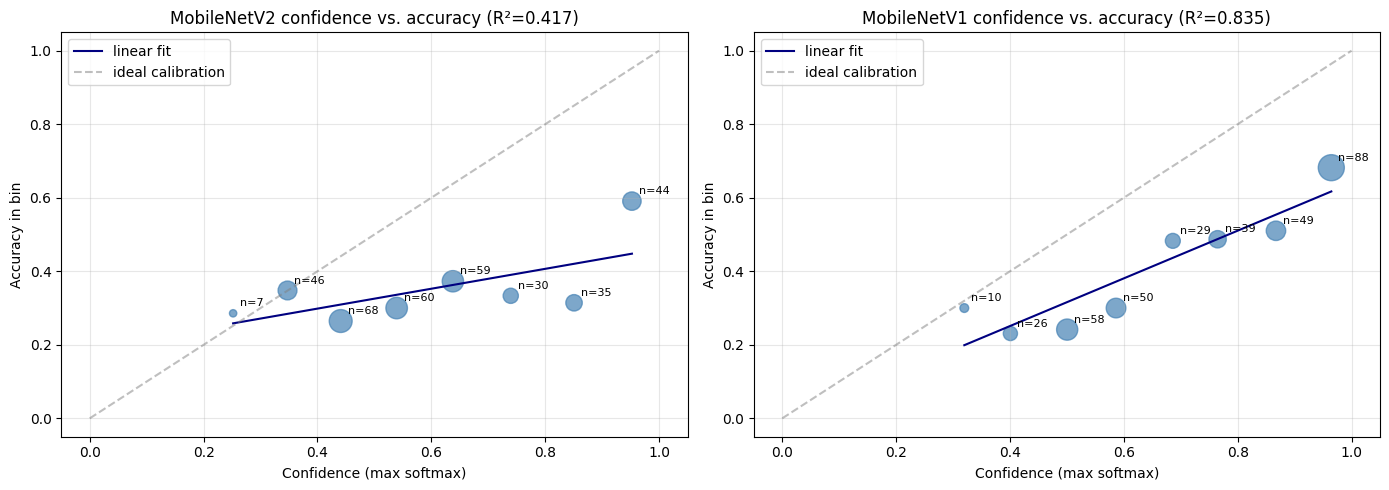

In [19]:
models = {"MLP": mlp, "CNN": cnn, "MLP v2": mlp_v2, "CNN v2": cnn_v2,
          "MobileNetV2": mbv2, "MobileNetV1": mbv1}
results = {}
for name, model in models.items():
    proba = model.predict(test_ds, verbose=0)
    pred = np.argmax(proba, axis=1)
    results[name] = {
        "proba":    proba,
        "pred":     pred,
        "acc":      accuracy_score(y_test, pred),
        "acc_pm1":  np.mean(np.abs(y_test - pred) <= 1),
        "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
    }

# Majority-class baseline: predict the train-set mode on every test instance
majority_class = pd.Series(y_train).mode().iloc[0]
y_pred_majority = np.full(len(y_test), majority_class)
results["Majority"] = {
    "pred":     y_pred_majority,
    "acc":      accuracy_score(y_test, y_pred_majority),
    "acc_pm1":  np.mean(np.abs(y_test - y_pred_majority) <= 1),
    "f1_macro": f1_score(y_test, y_pred_majority, average="macro", zero_division=0),
}

# Headline metrics
print(f"{'Model':<14} {'Accuracy':>10} {'±1 acc':>10} {'F1 macro':>10}")
print("-" * 46)
for name in ["Majority", "MLP", "CNN", "MLP v2", "CNN v2", "MobileNetV2", "MobileNetV1"]:
    r = results[name]
    print(f"{name:<14} {r['acc']:>10.3f} {r['acc_pm1']:>10.3f} {r['f1_macro']:>10.3f}")

# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for ax, name in zip(axes, ["MLP", "CNN", "MLP v2", "CNN v2", "MobileNetV2", "MobileNetV1"]):
    r = results[name]
    cm = confusion_matrix(y_test, r["pred"], labels=range(6))
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"{name} (acc={r['acc']:.2f}, ±1={r['acc_pm1']:.2f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    for i in range(6):
        for j in range(6):
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=9)
plt.tight_layout()
plt.show()

# Accuracy stratified by annotation difficulty
test_effort = df.loc[test_idx, "effort"].to_numpy()
print("\nAccuracy stratified by annotation effort:")
header = f"{'Model':<14}" + "".join(f"{l:>20}" for l in ["Easy", "Moderate", "Difficult"])
print(header)
print("-" * len(header))
for name in ["MLP", "CNN", "MLP v2", "CNN v2", "MobileNetV2", "MobileNetV1"]:
    cells = []
    for eff in [0, 1, 2]:
        m = test_effort == eff
        cells.append(f"{accuracy_score(y_test[m], results[name]['pred'][m]):.3f} (n={m.sum()})")
    print(f"{name:<14}" + "".join(f"{c:>20}" for c in cells))

# MobileNet confidence vs accuracy (paper §3.2 reports R²=0.896 on Dataset 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ["MobileNetV2", "MobileNetV1"]):
    proba = results[name]["proba"]
    pred  = results[name]["pred"]
    confidence = proba.max(axis=1)
    correct    = (pred == y_test).astype(float)
    bins = np.linspace(confidence.min(), 1.0, 9)
    bin_acc, bin_n, bin_centers = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (confidence >= lo) & (confidence < hi if hi < 1.0 else confidence <= hi)
        if m.sum() > 0:
            bin_acc.append(correct[m].mean())
            bin_n.append(m.sum())
            bin_centers.append(confidence[m].mean())
    bin_acc, bin_n, bin_centers = map(np.array, (bin_acc, bin_n, bin_centers))
    ax.scatter(bin_centers, bin_acc, s=bin_n * 4, alpha=0.7, color="steelblue")
    for x, y, n in zip(bin_centers, bin_acc, bin_n):
        ax.annotate(f"n={n}", (x, y), fontsize=8, xytext=(5, 5), textcoords="offset points")
    if len(bin_centers) >= 2:
        slope, intercept = np.polyfit(bin_centers, bin_acc, 1)
        xs = np.linspace(bin_centers.min(), bin_centers.max(), 50)
        ax.plot(xs, slope * xs + intercept, color="navy", label="linear fit")
        r2 = np.corrcoef(bin_centers, bin_acc)[0, 1] ** 2
    else:
        r2 = float("nan")
    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5, label="ideal calibration")
    ax.set_xlabel("Confidence (max softmax)")
    ax.set_ylabel("Accuracy in bin")
    ax.set_title(f"{name} confidence vs. accuracy (R²={r2:.3f})")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Statistical Analyses

Three analyses motivated by Cheng et al. (2021): a one-tailed z-test on accuracy across annotation-difficulty strata (paper §3.2), a building-attribute correlation analysis on damage class vs. number of stories and bounding-box area (paper §4.2 / Table 11), and a bounding-box-area-filtered evaluation testing the §12.3 hypothesis that small upscaled patches drive a measurable share of misclassifications. Analyses are run on MobileNetV1 since it is the paper-faithful model and has the more diagnostic confusion-matrix structure.

In [20]:
# One-tailed z-test (95%) on accuracy across annotation difficulty.
# Replicates Cheng et al. (2021) §3.2: easy samples should be classified more
# accurately than moderate or difficult samples.
from statsmodels.stats.proportion import proportions_ztest

target_model = "MobileNetV1"
test_effort  = df.loc[test_idx, "effort"].to_numpy()
pred         = results[target_model]["pred"]
correct      = (pred == y_test).astype(int)

print(f"Annotation-difficulty z-tests on {target_model} (one-tailed, 95% confidence)\n")
strata = {0: "easy", 1: "moderate", 2: "difficult"}
counts, ns, accs = {}, {}, {}
for k, label in strata.items():
    m = test_effort == k
    counts[k], ns[k] = correct[m].sum(), m.sum()
    accs[k] = counts[k] / max(ns[k], 1)
    print(f"  {label:9s}: n={ns[k]:3d}, correct={counts[k]:3d}, acc={accs[k]:.3f}")

print(f"\n{'comparison':<24} {'z':>8} {'p (one-tail)':>14} {'reject H0?':>12}")
print("-" * 60)
for a, b in [(0, 1), (0, 2), (1, 2)]:
    # H1: stratum a has higher accuracy than stratum b
    z, p_two = proportions_ztest(
        count=[counts[a], counts[b]],
        nobs=[ns[a], ns[b]],
        alternative="larger",
    )
    sig = "yes" if p_two < 0.05 else "no"
    print(f"  {strata[a]:8s} > {strata[b]:9s} {z:>8.3f} {p_two:>14.4f} {sig:>12}")

Annotation-difficulty z-tests on MobileNetV1 (one-tailed, 95% confidence)

  easy     : n= 58, correct= 19, acc=0.328
  moderate : n=248, correct=113, acc=0.456
  difficult: n= 43, correct= 24, acc=0.558

comparison                      z   p (one-tail)   reject H0?
------------------------------------------------------------
  easy     > moderate    -1.773         0.9619           no
  easy     > difficult   -2.317         0.9897           no
  moderate > difficult   -1.243         0.8931           no


In [21]:
# Building-attribute analysis: damage class vs. number of stories.
# Replicates the structure of Cheng et al. (2021) Table 11 / §4.2.
from statsmodels.stats.weightstats import ztest

# One row per unique test-set building, with its modal damage and modal stories
test_buildings = (df.loc[test_idx]
                    .groupby("building_id")
                    .agg(damage=("damage", lambda s: s.mode().iloc[0]),
                         stories=("stories", lambda s: s.mode().iloc[0]))
                    .reset_index())

print(f"Building-attribute analysis on test set ({len(test_buildings)} unique buildings)\n")

print("Stories distribution:")
print(test_buildings["stories"].value_counts().sort_index().to_string())

print("\nMean damage by number of stories:")
for s, grp in test_buildings.groupby("stories"):
    print(f"  {s} stories: n={len(grp):3d}, mean damage={grp['damage'].mean():.3f}")

# Two-tailed z-test (1-story vs. 2+-story). Skipped if either stratum is too small.
one_story   = test_buildings.loc[test_buildings["stories"] == 1, "damage"].to_numpy()
multi_story = test_buildings.loc[test_buildings["stories"] >= 2, "damage"].to_numpy()
if len(one_story) >= 5 and len(multi_story) >= 5:
    z, p = ztest(one_story, multi_story, alternative="two-sided")
    print(f"\nTwo-tailed z-test (1-story vs. 2+-story): z = {z:.3f}, p = {p:.4f}")
    print(f"  reject H0 (no difference)? {'yes' if p < 0.05 else 'no'}")
else:
    print(f"\nz-test skipped: too few buildings in one stratum "
          f"(n_1story={len(one_story)}, n_2plus={len(multi_story)}). "
          f"With only 30 distinct buildings in test, the building-stratified split puts a hard floor on what this analysis can detect.")

Building-attribute analysis on test set (30 unique buildings)

Stories distribution:
stories
1    28
2     2

Mean damage by number of stories:
  1 stories: n= 28, mean damage=2.714
  2 stories: n=  2, mean damage=2.000

z-test skipped: too few buildings in one stratum (n_1story=28, n_2plus=2). With only 30 distinct buildings in test, the building-stratified split puts a hard floor on what this analysis can detect.


## Example Error Grid

For each MobileNet variant, a 6×6 grid of test patches arranged by (true class, predicted class). The diagonal shows correctly-classified examples; off-diagonal cells visualize specific error patterns from the confusion matrices above. Cells marked with "—" indicate no test sample fell in that (true, pred) combination. Cell counts (`n=...`) report how many test samples landed there; the displayed image is the first such sample in test-set order.

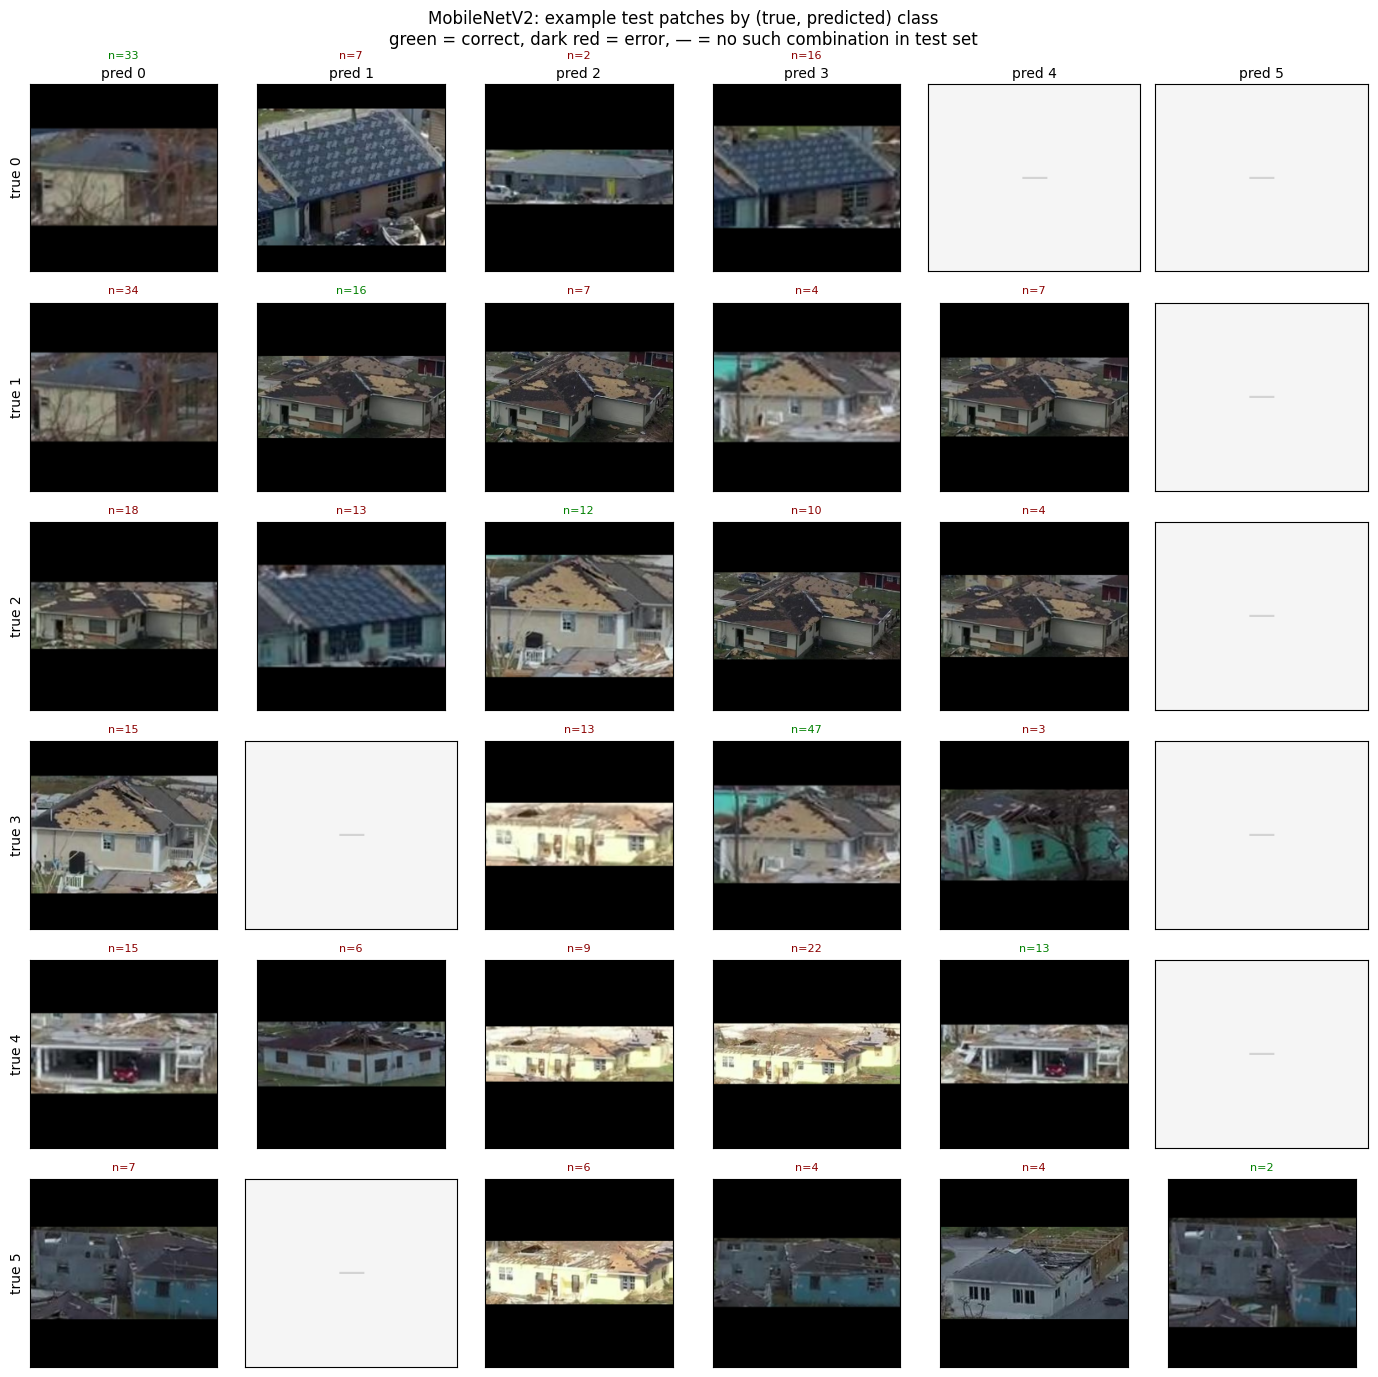

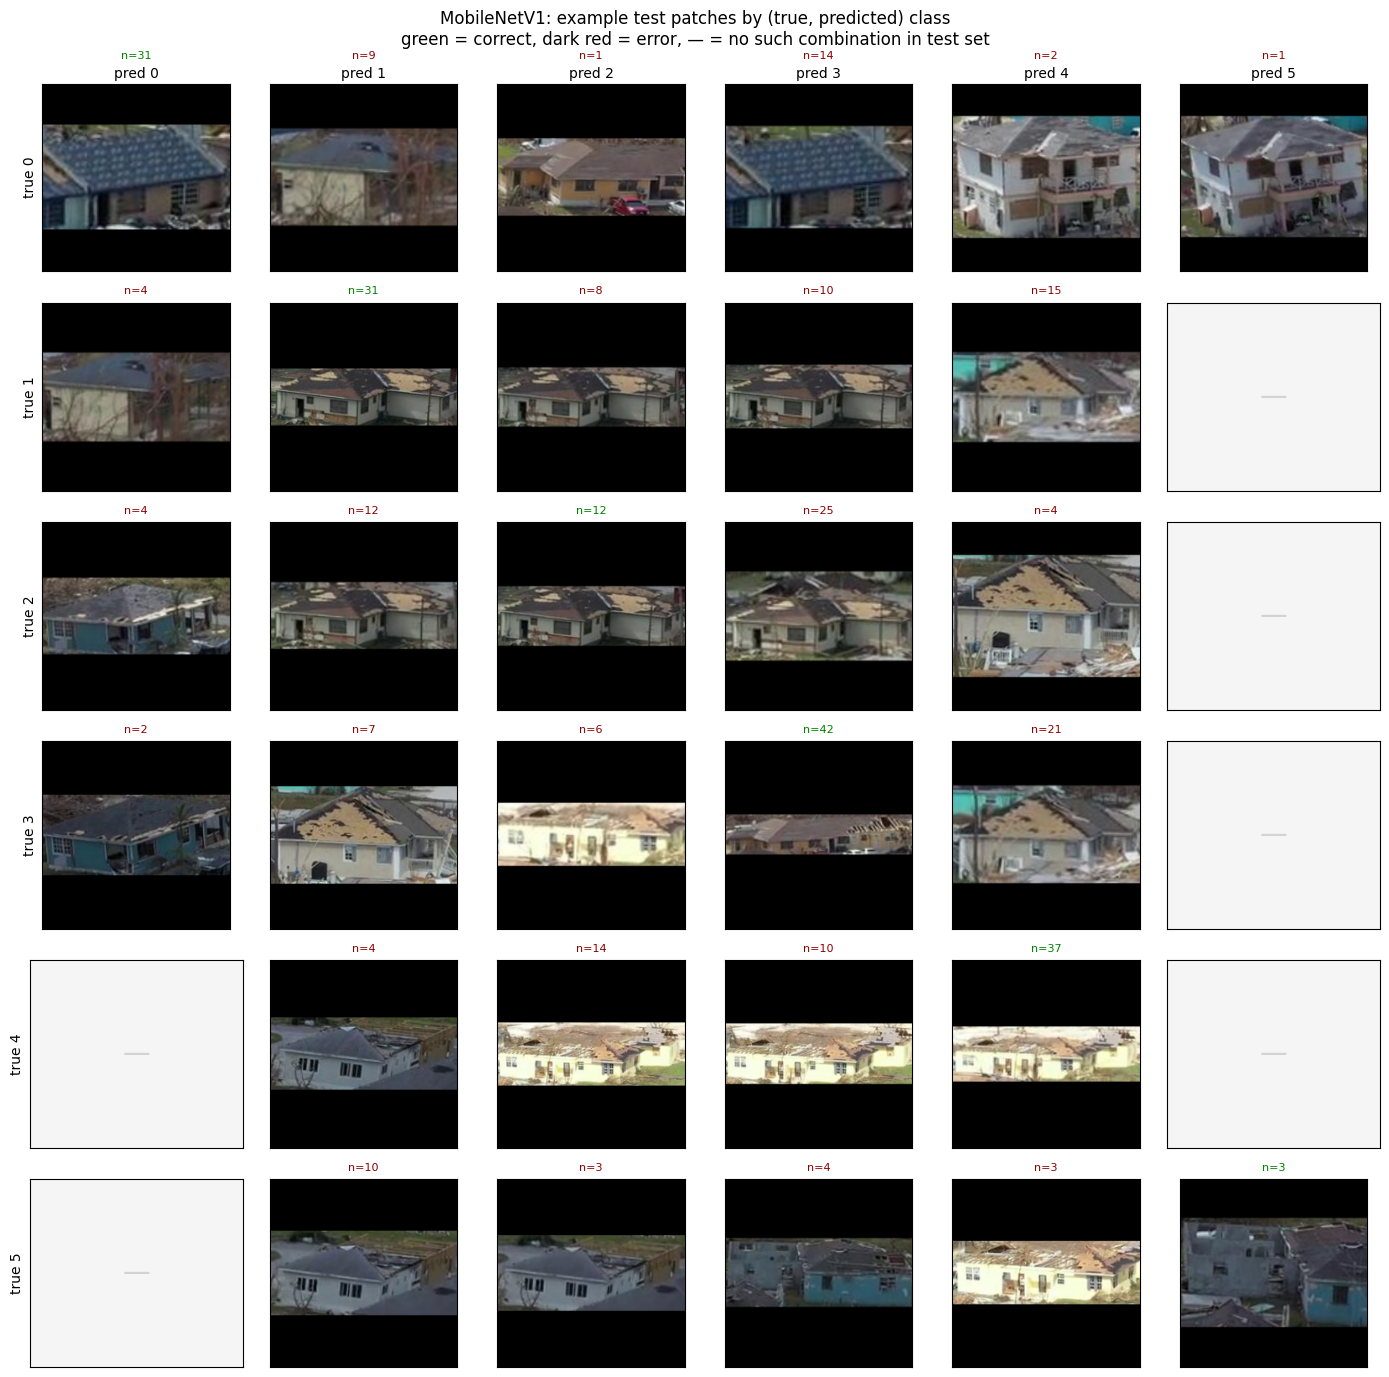

In [22]:
# Example error grid: one patch per (true class, predicted class) cell.
# Two figures, one per MobileNet variant. Diagonal = correct predictions;
# off-diagonal = errors. Empty cells where no test sample falls in that combination.
def plot_error_grid(model_name, results, y_test, test_idx, df, patches):
    pred = results[model_name]["pred"]
    fig, axes = plt.subplots(6, 6, figsize=(14, 14))
    for true_cls in range(6):
        for pred_cls in range(6):
            ax = axes[true_cls, pred_cls]
            mask = (y_test == true_cls) & (pred == pred_cls)
            local_indices = np.where(mask)[0]
            if len(local_indices) > 0:
                # Pick a deterministic example: first matching test sample
                df_idx = test_idx[local_indices[0]]
                ax.imshow(patches[df_idx])
                ax.set_title(f"n={len(local_indices)}", fontsize=8,
                             color=("green" if true_cls == pred_cls else "darkred"))
            else:
                ax.set_facecolor("#f5f5f5")
                ax.text(0.5, 0.5, "—", ha="center", va="center",
                        transform=ax.transAxes, color="lightgray", fontsize=20)
            ax.set_xticks([]); ax.set_yticks([])
            if pred_cls == 0:
                ax.set_ylabel(f"true {true_cls}", fontsize=10)
            if true_cls == 0:
                ax.set_xlabel(f"pred {pred_cls}", fontsize=10)
                ax.xaxis.set_label_position("top")
    plt.suptitle(f"{model_name}: example test patches by (true, predicted) class\n"
                 f"green = correct, dark red = error, — = no such combination in test set",
                 fontsize=12)
    plt.tight_layout()
    plt.show()

for name in ["MobileNetV2", "MobileNetV1"]:
    plot_error_grid(name, results, y_test, test_idx, df, patches)

## 5-Fold Building-Stratified Cross-Validation
The headline numbers above come from a single building-stratified split. Cross-validation checks that the per-model ordering is stable across different partitionings — i.e., that "MobileNetV1 best, MLP worst" is a property of the architectures rather than a lucky split.
Cross-validation follows the same building-stratification rule as the headline split: each fold's train/val partition is at the building level, so no physical building appears in both train and val of the same fold. The held-out test set (~29 buildings) stays held out across all folds. We run 5-fold StratifiedKFold over the remaining 118 train+val buildings, stratified by modal damage class.
Per fold we train all six architectures (MLP, CNN, MLP v2, CNN v2, MobileNetV2, MobileNetV1) and record val accuracy. Each model uses its own headline augmentation pipeline, so CV results are directly comparable to the single-split numbers. MobileNets use a shorter two-stage budget (10 epochs head + 25 epochs fine-tune) to keep total CV runtime under ~2 hours on L4; from-scratch models use 50 epochs.

In [23]:
import gc
from sklearn.model_selection import StratifiedKFold

CV_K = 5
CV_EPOCHS_FROMSCRATCH = 50
CV_EPOCHS_HEAD = 10
CV_EPOCHS_FINETUNE = 25

trainval_buildings = building_summary[~building_summary["building_id"].isin(test_ids)].reset_index(drop=True)
print(f"CV pool: {len(trainval_buildings)} buildings (test held out: {len(test_ids)} buildings)")
print("CV class distribution (modal damage):")
print(trainval_buildings["modal_damage"].value_counts().sort_index())


def build_fold_train_val(fold_train_bld, fold_val_bld):
    fold_train_idx = df.index[df["building_id"].isin(fold_train_bld)].to_numpy()
    fold_val_idx   = df.index[df["building_id"].isin(fold_val_bld)].to_numpy()
    Xtr, ytr = patches[fold_train_idx], df.loc[fold_train_idx, "damage"].to_numpy()
    Xvl, yvl = patches[fold_val_idx],   df.loc[fold_val_idx,   "damage"].to_numpy()

    def make_train(augment_fn):
        return (tf.data.Dataset.from_tensor_slices((Xtr, ytr))
                .shuffle(len(Xtr), seed=42).batch(BATCH)
                .map(lambda x, y: (augment_fn(x, training=True), y), num_parallel_calls=AUTOTUNE)
                .prefetch(AUTOTUNE))

    tr_orig = make_train(augment)
    tr_mod  = make_train(augment_modern)
    vl_ds = tf.data.Dataset.from_tensor_slices((Xvl, yvl)).batch(BATCH).prefetch(AUTOTUNE)
    return tr_orig, tr_mod, vl_ds, with_one_hot(tr_mod), with_one_hot(vl_ds)


def free_memory():
    gc.collect()
    tf.keras.backend.clear_session()


def build_mlp_fresh():
    free_memory(); tf.random.set_seed(42)
    return tf.keras.models.clone_model(mlp)

def build_cnn_fresh():
    free_memory(); tf.random.set_seed(42)
    return tf.keras.models.clone_model(cnn)

def build_mlp_v2_fresh():
    free_memory(); tf.random.set_seed(42)
    return tf.keras.models.clone_model(mlp_v2)

def build_cnn_v2_fresh():
    free_memory(); tf.random.set_seed(42)
    return tf.keras.models.clone_model(cnn_v2)

def build_mbv2_fresh():
    free_memory(); tf.random.set_seed(42)
    backbone = tf.keras.applications.MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    backbone.trainable = False
    inputs = tf.keras.Input((224, 224, 3))
    x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)
    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    out = tf.keras.layers.Dense(6, activation="softmax")(x)
    return tf.keras.Model(inputs, out), backbone

def build_mbv1_fresh():
    free_memory(); tf.random.set_seed(42)
    backbone = tf.keras.applications.MobileNet(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    backbone.trainable = False
    inputs = tf.keras.Input((224, 224, 3))
    x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)
    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    out = tf.keras.layers.Dense(6, activation="softmax")(x)
    return tf.keras.Model(inputs, out), backbone


cv_results = []
skf = StratifiedKFold(n_splits=CV_K, shuffle=True, random_state=42)

for fold, (tr_idx, vl_idx) in enumerate(skf.split(trainval_buildings, trainval_buildings["modal_damage"]), 1):
    fold_train_bld = set(trainval_buildings.iloc[tr_idx]["building_id"])
    fold_val_bld   = set(trainval_buildings.iloc[vl_idx]["building_id"])
    tr_orig, tr_mod, vl_ds, tr_mod_oh, vl_ds_oh = build_fold_train_val(fold_train_bld, fold_val_bld)
    print(f"\n{'='*70}\nFold {fold}/{CV_K}: {len(fold_train_bld)} train bld, {len(fold_val_bld)} val bld\n{'='*70}")

    # MLP — original recipe (sparse CE + plain Adam + light aug)
    m = build_mlp_fresh()
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h = m.fit(tr_orig, validation_data=vl_ds, epochs=CV_EPOCHS_FROMSCRATCH,
              callbacks=make_callbacks(patience=8), verbose=0)
    cv_results.append({"fold": fold, "model": "MLP", "val_acc": max(h.history["val_accuracy"])})
    print(f"  MLP:         val_acc = {cv_results[-1]['val_acc']:.3f}")
    del m, h; free_memory()

    # CNN — original recipe
    m = build_cnn_fresh()
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h = m.fit(tr_orig, validation_data=vl_ds, epochs=CV_EPOCHS_FROMSCRATCH,
              callbacks=make_callbacks(patience=8), verbose=0)
    cv_results.append({"fold": fold, "model": "CNN", "val_acc": max(h.history["val_accuracy"])})
    print(f"  CNN:         val_acc = {cv_results[-1]['val_acc']:.3f}")
    del m, h; free_memory()

    # MLP v2 — modernized recipe (label smoothing + AdamW + heavier aug)
    m = build_mlp_v2_fresh()
    m.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=WEIGHT_DECAY),
              loss=loss_smoothed, metrics=["accuracy"])
    h = m.fit(tr_mod_oh, validation_data=vl_ds_oh, epochs=CV_EPOCHS_FROMSCRATCH,
              callbacks=make_callbacks(patience=8), verbose=0)
    cv_results.append({"fold": fold, "model": "MLP v2", "val_acc": max(h.history["val_accuracy"])})
    print(f"  MLP v2:      val_acc = {cv_results[-1]['val_acc']:.3f}")
    del m, h; free_memory()

    # CNN v2 — modernized recipe
    m = build_cnn_v2_fresh()
    m.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=WEIGHT_DECAY),
              loss=loss_smoothed, metrics=["accuracy"])
    h = m.fit(tr_mod_oh, validation_data=vl_ds_oh, epochs=CV_EPOCHS_FROMSCRATCH,
              callbacks=make_callbacks(patience=8), verbose=0)
    cv_results.append({"fold": fold, "model": "CNN v2", "val_acc": max(h.history["val_accuracy"])})
    print(f"  CNN v2:      val_acc = {cv_results[-1]['val_acc']:.3f}")
    del m, h; free_memory()

    # MobileNetV2 — paper's recipe, light aug
    m, bb = build_mbv2_fresh()
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h1 = m.fit(tr_orig, validation_data=vl_ds, epochs=CV_EPOCHS_HEAD,
               callbacks=make_callbacks(patience=5), verbose=0)
    bb.trainable = True
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h2 = m.fit(tr_orig, validation_data=vl_ds, epochs=CV_EPOCHS_HEAD + CV_EPOCHS_FINETUNE,
               initial_epoch=len(h1.history["loss"]),
               callbacks=make_callbacks(patience=8), verbose=0)
    cv_results.append({"fold": fold, "model": "MobileNetV2", "val_acc": max(h2.history["val_accuracy"])})
    print(f"  MobileNetV2: val_acc = {cv_results[-1]['val_acc']:.3f}")
    del m, h1, h2, bb; free_memory()

    # MobileNetV1
    m, bb = build_mbv1_fresh()
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h1 = m.fit(tr_orig, validation_data=vl_ds, epochs=CV_EPOCHS_HEAD,
               callbacks=make_callbacks(patience=5), verbose=0)
    bb.trainable = True
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h2 = m.fit(tr_orig, validation_data=vl_ds, epochs=CV_EPOCHS_HEAD + CV_EPOCHS_FINETUNE,
               initial_epoch=len(h1.history["loss"]),
               callbacks=make_callbacks(patience=8), verbose=0)
    cv_results.append({"fold": fold, "model": "MobileNetV1", "val_acc": max(h2.history["val_accuracy"])})
    print(f"  MobileNetV1: val_acc = {cv_results[-1]['val_acc']:.3f}")
    del m, h1, h2, bb; free_memory()

    pd.DataFrame(cv_results).to_csv("cv_dorianet.csv", index=False)

cv_df = pd.DataFrame(cv_results)
cv_df.to_csv("cv_dorianet.csv", index=False)

print(f"\n{'='*70}\nCV summary: val accuracy mean ± std\n{'='*70}")
agg = cv_df.groupby("model")["val_acc"].agg(["mean", "std"]).round(3)
print(agg)

CV pool: 117 buildings (test held out: 30 buildings)
CV class distribution (modal damage):
modal_damage
0    12
1    21
2    18
3    33
4    22
5    11
Name: count, dtype: int64

Fold 1/5: 93 train bld, 24 val bld
  MLP:         val_acc = 0.187
  CNN:         val_acc = 0.183
  MLP v2:      val_acc = 0.195
  CNN v2:      val_acc = 0.183
  MobileNetV2: val_acc = 0.424
  MobileNetV1: val_acc = 0.363

Fold 2/5: 93 train bld, 24 val bld
  MLP:         val_acc = 0.349
  CNN:         val_acc = 0.344
  MLP v2:      val_acc = 0.397
  CNN v2:      val_acc = 0.234
  MobileNetV2: val_acc = 0.435
  MobileNetV1: val_acc = 0.493

Fold 3/5: 94 train bld, 23 val bld
  MLP:         val_acc = 0.399
  CNN:         val_acc = 0.399
  MLP v2:      val_acc = 0.256
  CNN v2:      val_acc = 0.336
  MobileNetV2: val_acc = 0.570
  MobileNetV1: val_acc = 0.605

Fold 4/5: 94 train bld, 23 val bld
  MLP:         val_acc = 0.500
  CNN:         val_acc = 0.500
  MLP v2:      val_acc = 0.434
  CNN v2:      val_acc = 0.

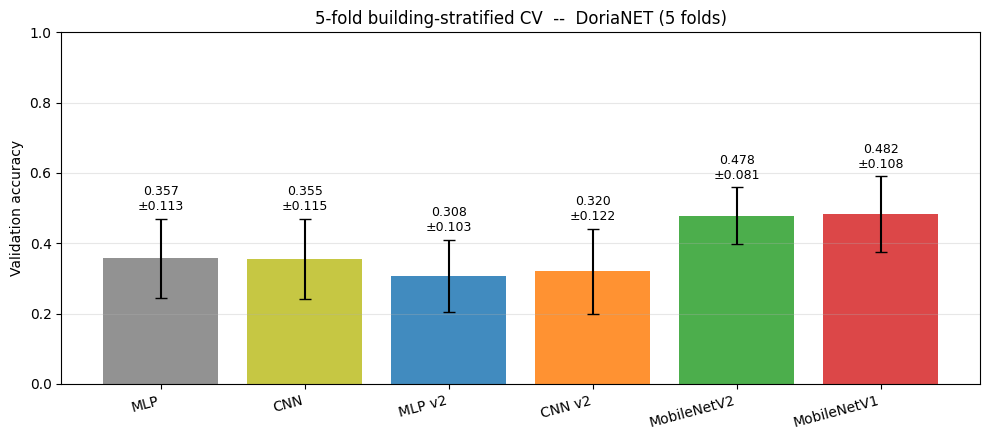

In [24]:
fig, ax = plt.subplots(figsize=(10, 4.5))
order = ["MLP", "CNN", "MLP v2", "CNN v2", "MobileNetV2", "MobileNetV1"]
positions = np.arange(len(order))
means = [cv_df[cv_df["model"] == m]["val_acc"].mean() for m in order]
stds  = [cv_df[cv_df["model"] == m]["val_acc"].std()  for m in order]
ax.bar(positions, means, yerr=stds, capsize=4,
       color=["C7", "C8", "C0", "C1", "C2", "C3"], alpha=0.85)
ax.set_xticks(positions)
ax.set_xticklabels(order, rotation=15, ha="right")
ax.set_ylabel("Validation accuracy")
ax.set_title(f"5-fold building-stratified CV  --  DoriaNET ({CV_K} folds)")
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(0, 1)
for x, m, s in zip(positions, means, stds):
    ax.text(x, m + s + 0.015, f"{m:.3f}\n±{s:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("fig_cv_dorianet.png", dpi=140, bbox_inches="tight")
plt.show()

## End-to-End Pipeline: YOLO Building Detection -> Damage Classification
The classification pipeline so far has used ground-truth masks to crop buildings from frames — i.e., it answers "given a building, what is its damage class?" but does not answer "given a frame, where are the damaged buildings?" To close the loop, we add a YOLO11 building detector trained on the same dataset (using the masks to derive bounding boxes), then chain it to the best classifier (MobileNetV1) to produce a frame-in / damage-out pipeline.
Why YOLO vs. semantic segmentation? The masks in the DoriaNET dataset are instance-level (one mask per building per frame). Object detection is the natural framing — each instance becomes a single bounding box, and non-overlapping crops are straightforward to feed into the existing classifier. YOLO11n (the smallest YOLO11 variant) was chosen as a 2025 state-of-the-art detector with a clean Python API; training fine-tunes from COCO-pretrained weights so a few hundred frames is enough.
Frame-level split for the detector. Detection is class-agnostic (single class: "building"), so the building-stratified split used for classification is not required. We split frames 80/20 train/val. Some frames may contain buildings that are in the classification test set; that is fine for the detector (which does not predict damage), and the classifier was trained without seeing any of those buildings.
End-to-end evaluation. For each frame in the classification test set, we run YOLO inference, match each predicted box to a ground-truth building by IoU (threshold 0.5), crop the matched predicted box, and pass it through MobileNetV1. We report (1) detection recall and mean IoU on test frames, (2) end-to-end exact and ±1-class accuracy on matched buildings, and compare to the ground-truth-mask baseline.

In [25]:
!pip install -q ultralytics

import shutil
from ultralytics import YOLO

YOLO_ROOT = Path("yolo_data")
if YOLO_ROOT.exists():
    shutil.rmtree(YOLO_ROOT)
for split in ["train", "val"]:
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

# Identify frames containing any test-split building — held out from YOLO entirely
# so the detector never sees a test building during training. Frames in the pool
# have all their buildings labeled (no label noise from partial annotation).
test_buildings = set(df.loc[df["split"] == "test", "building_id"].unique())
test_relevant_frames = set()
for fname in df["frame_name"].unique():
    bld_in_frame = set(df.loc[df["frame_name"] == fname, "building_id"].unique())
    if bld_in_frame & test_buildings:
        test_relevant_frames.add(fname)

yolo_pool = sorted(set(df["frame_name"].unique()) - test_relevant_frames)
print(f"YOLO pool: {len(yolo_pool)} frames (excluded {len(test_relevant_frames)} test-relevant)")

np.random.seed(42)
shuffled = np.random.permutation(yolo_pool)
n_train = int(len(shuffled) * 0.80)
yolo_train_frames = set(shuffled[:n_train])
yolo_val_frames = set(shuffled[n_train:])
print(f"YOLO frame split: {len(yolo_train_frames)} train, {len(yolo_val_frames)} val")


def mask_to_yolo_bbox(mask_bool, img_h, img_w):
    rows = np.where(np.any(mask_bool, axis=1))[0]
    cols = np.where(np.any(mask_bool, axis=0))[0]
    if len(rows) == 0 or len(cols) == 0:
        return None
    y0, y1 = rows[0], rows[-1]
    x0, x1 = cols[0], cols[-1]
    cx = ((x0 + x1) / 2) / img_w
    cy = ((y0 + y1) / 2) / img_h
    w  = (x1 - x0 + 1) / img_w
    h  = (y1 - y0 + 1) / img_h
    return cx, cy, w, h

for split, frames in [("train", yolo_train_frames), ("val", yolo_val_frames)]:
    for fname in frames:
        frame = plt.imread(FRAME_DIR / fname)
        img_h, img_w = frame.shape[:2]
        shutil.copy(FRAME_DIR / fname, YOLO_ROOT / "images" / split / fname)

        # Label all buildings in the frame. By construction, no test-split buildings
        # are in these frames, so labeling everything introduces no leakage.
        lines = []
        for _, row in df[df["frame_name"] == fname].iterrows():
            mask = plt.imread(MASK_DIR / row["mask_name"])
            mb = mask.mean(axis=-1) > 127 if mask.ndim == 3 else mask > 127
            bbox = mask_to_yolo_bbox(mb, img_h, img_w)
            if bbox is not None:
                cx, cy, w, h = bbox
                lines.append(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        label_path = YOLO_ROOT / "labels" / split / (Path(fname).stem + ".txt")
        label_path.write_text("\n".join(lines))

data_yaml = YOLO_ROOT / "data.yaml"
data_yaml.write_text(
    f"path: {YOLO_ROOT.absolute()}\n"
    "train: images/train\n"
    "val: images/val\n"
    "nc: 1\n"
    "names: ['building']\n"
)
print(f"\nYOLO dataset built at {YOLO_ROOT.absolute()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO pool: 91 frames (excluded 180 test-relevant)
YOLO frame split: 72 train, 19 val

YOLO dataset built at /content/AI-FinalProject-GroupSCR/DoriaNETProject/yolo_data


In [ ]:
import gc
gc.collect()
tf.keras.backend.clear_session()

# Free CUDA-side allocations from Keras models that are still alive
import torch
torch.cuda.empty_cache()

# Also explicitly del the largest in-memory tensors
try:
    del mbv2_swept, mbv1_swept, hist_mbv2_swept, hist_mbv1_swept
except NameError:
    pass
gc.collect(); torch.cuda.empty_cache()

yolo_model = YOLO("yolo11n.pt")
yolo_results = yolo_model.train(
    data=str(data_yaml),
    epochs=50,
    imgsz=640,
    batch=4,          # halved from 8
    workers=2,        # reduced from default 8 — fewer subprocess workers
    patience=15,
    seed=42,
    close_mosaic=0,
    name="dorianet_yolo",
    project="yolo_runs",
    verbose=False,
)
best_yolo_path = Path("runs/detect/yolo_runs/dorianet_yolo/weights/best.pt")
print(f"Best YOLO weights: {best_yolo_path}")
yolo_best = YOLO(str(best_yolo_path))
val_metrics = yolo_best.val(data=str(data_yaml), imgsz=640, verbose=False)
print(f"\nYOLO val metrics:")
print(f"  mAP@0.5      = {val_metrics.box.map50:.3f}")
print(f"  mAP@0.5:0.95 = {val_metrics.box.map:.3f}")
print(f"  precision    = {val_metrics.box.mp:.3f}")
print(f"  recall       = {val_metrics.box.mr:.3f}")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=dorianet_yolo, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, per

## End-to-End Evaluation: YOLO Detection -> MobileNetV1 Classification
For each ground-truth building in the classification test set, find its frame, run YOLO inference, match its GT bbox to the highest-IoU predicted bbox (IoU >= 0.5), crop that predicted bbox, feed it through MobileNetV1, and compare the predicted damage class to the true class.

In [ ]:
IOU_THRESHOLD = 0.5

def iou_xyxy(a, b):
    x0 = max(a[0], b[0]); y0 = max(a[1], b[1])
    x1 = min(a[2], b[2]); y1 = min(a[3], b[3])
    inter = max(0, x1 - x0) * max(0, y1 - y0)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

def gt_bbox_xyxy(mask_bool):
    rows = np.where(np.any(mask_bool, axis=1))[0]
    cols = np.where(np.any(mask_bool, axis=0))[0]
    return (cols[0], rows[0], cols[-1] + 1, rows[-1] + 1)

def crop_xyxy(frame, bbox, size=224):
    x0, y0, x1, y1 = [int(v) for v in bbox]
    x0, y0 = max(0, x0), max(0, y0)
    x1, y1 = min(frame.shape[1], x1), min(frame.shape[0], y1)
    crop = frame[y0:y1, x0:x1]
    h, w = crop.shape[:2]
    if h == 0 or w == 0:
        return np.zeros((size, size, 3), dtype=np.uint8)
    side = max(h, w)
    out = np.zeros((side, side, 3), dtype=np.uint8)
    out[(side - h) // 2:(side - h) // 2 + h,
        (side - w) // 2:(side - w) // 2 + w] = crop
    return tf.image.resize(out, (size, size), method="bilinear").numpy().astype(np.uint8)


test_df = df.loc[df["split"] == "test"].copy()
test_frames = test_df["frame_name"].unique()
print(f"End-to-end eval: {len(test_df)} test instances across {len(test_frames)} frames")

frame_predictions = {}
for fname in test_frames:
    res = yolo_best(str(FRAME_DIR / fname), verbose=False)[0]
    if res.boxes is not None and len(res.boxes) > 0:
        boxes_xyxy = res.boxes.xyxy.cpu().numpy()
        confs      = res.boxes.conf.cpu().numpy()
    else:
        boxes_xyxy = np.zeros((0, 4))
        confs      = np.zeros(0)
    frame_predictions[fname] = (boxes_xyxy, confs)

e2e_rows = []
for _, row in test_df.iterrows():
    frame = plt.imread(FRAME_DIR / row["frame_name"])
    mask  = plt.imread(MASK_DIR / row["mask_name"])
    mb = mask.mean(axis=-1) > 127 if mask.ndim == 3 else mask > 127
    gt_box = gt_bbox_xyxy(mb)
    pred_boxes, _ = frame_predictions[row["frame_name"]]
    if len(pred_boxes) == 0:
        e2e_rows.append({"idx": row.name, "matched": False, "iou": 0.0, "pred_damage": None})
        continue
    ious = np.array([iou_xyxy(gt_box, pb) for pb in pred_boxes])
    j = int(np.argmax(ious))
    if ious[j] >= IOU_THRESHOLD:
        crop = crop_xyxy(frame, pred_boxes[j])
        prob = mbv1.predict(crop[None], verbose=0)[0]
        e2e_rows.append({"idx": row.name, "matched": True, "iou": float(ious[j]),
                         "pred_damage": int(np.argmax(prob))})
    else:
        e2e_rows.append({"idx": row.name, "matched": False, "iou": float(ious[j]), "pred_damage": None})

e2e = pd.DataFrame(e2e_rows).set_index("idx")
e2e["true_damage"] = test_df.loc[e2e.index, "damage"].values

n_total   = len(e2e)
n_matched = e2e["matched"].sum()
detection_recall = n_matched / n_total
mean_iou_matched = e2e.loc[e2e["matched"], "iou"].mean()

matched = e2e[e2e["matched"]]
e2e_exact = (matched["pred_damage"] == matched["true_damage"]).mean() if n_matched else 0.0
e2e_pm1   = (np.abs(matched["pred_damage"] - matched["true_damage"]) <= 1).mean() if n_matched else 0.0
e2e_exact_overall = (matched["pred_damage"] == matched["true_damage"]).sum() / n_total
e2e_pm1_overall   = (np.abs(matched["pred_damage"] - matched["true_damage"]) <= 1).sum() / n_total

mask_exact = results["MobileNetV1"]["acc"]
mask_pm1   = results["MobileNetV1"]["acc_pm1"]

print(f"\n{'='*60}")
print(f"End-to-End Pipeline Results")
print(f"{'='*60}")
print(f"Detection")
print(f"  recall (IoU >= {IOU_THRESHOLD}):   {detection_recall:.3f}  ({n_matched}/{n_total})")
print(f"  mean IoU on matched:    {mean_iou_matched:.3f}")
print(f"\nClassification on matched buildings (conditional)")
print(f"  exact accuracy:         {e2e_exact:.3f}")
print(f"  +/- 1 class:            {e2e_pm1:.3f}")
print(f"\nEnd-to-end on full test set (missed detection counted as wrong)")
print(f"  exact accuracy:         {e2e_exact_overall:.3f}")
print(f"  +/- 1 class:            {e2e_pm1_overall:.3f}")
print(f"\nGround-truth-mask reference (MobileNetV1)")
print(f"  exact accuracy:         {mask_exact:.3f}")
print(f"  +/- 1 class:            {mask_pm1:.3f}")

pd.DataFrame([
    {"metric": "detection_recall",    "value": detection_recall},
    {"metric": "detection_mean_iou",  "value": mean_iou_matched},
    {"metric": "e2e_exact_matched",   "value": e2e_exact},
    {"metric": "e2e_pm1_matched",     "value": e2e_pm1},
    {"metric": "e2e_exact_overall",   "value": e2e_exact_overall},
    {"metric": "e2e_pm1_overall",     "value": e2e_pm1_overall},
    {"metric": "mask_exact_ref",      "value": mask_exact},
    {"metric": "mask_pm1_ref",        "value": mask_pm1},
]).to_csv("e2e_results.csv", index=False)

Qualitative: detected boxes vs. ground-truth bboxes on test frames

In [ ]:
sample_frames = (test_df[test_df.index.isin(e2e[e2e["matched"]].index)]
                 ["frame_name"].drop_duplicates().head(6).tolist())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, fname in zip(axes.flat, sample_frames):
    frame = plt.imread(FRAME_DIR / fname)
    ax.imshow(frame)

    for _, row in df[df["frame_name"] == fname].iterrows():
        mask = plt.imread(MASK_DIR / row["mask_name"])
        mb = mask.mean(axis=-1) > 127 if mask.ndim == 3 else mask > 127
        x0, y0, x1, y1 = gt_bbox_xyxy(mb)
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                    fill=False, edgecolor="lime", linewidth=2))

    pred_boxes, confs = frame_predictions.get(fname, (np.zeros((0, 4)), np.zeros(0)))
    for (x0, y0, x1, y1), c in zip(pred_boxes, confs):
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                    fill=False, edgecolor="red", linewidth=1.5))
        ax.text(x0, y0 - 4, f"{c:.2f}", color="red", fontsize=8, weight="bold")

    ax.set_title(fname, fontsize=10)
    ax.axis("off")

plt.suptitle("YOLO predictions (red) vs ground-truth bboxes (green) on test frames", fontsize=12)
plt.tight_layout()
plt.savefig("fig_yolo_qualitative.png", dpi=140, bbox_inches="tight")
plt.show()